In [4]:
import os
import numpy as np
from astropy.io import fits
from astropy.nddata import CCDData
import ccdproc
from astropy import units as u
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift
from collections import defaultdict
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
from PIL import Image 
from image_registration import chi2_shift
from image_registration.fft_tools import shift as img_shift
from scipy.signal import fftconvolve

### Approximation based on M83

In [2]:
# Base route
base_path = "./"

# Files
def get_fits_files(folder_path, prefix=""):
    files = []
    if not os.path.exists(folder_path):
        return []
    for root, dirs, filenames in os.walk(folder_path):
        for f in filenames:
            if f.lower().startswith(prefix.lower()) and f.lower().endswith(('.fits', '.fit')):
                files.append(os.path.join(root, f))
    return sorted(files)

print("Loading files...")

# Bias
bias_files = get_fits_files(os.path.join(base_path, "Bias"), "bias")

# Darks 120s
dark_files = get_fits_files(os.path.join(base_path, "Dark"), "dark")

# Dark Flats 
dark_flat_iu_files = get_fits_files(os.path.join(base_path, "Dark_flat", "i_u"), "dark_flat")
dark_flat_gr_files = get_fits_files(os.path.join(base_path, "Dark_flat", "g_r"), "dark_flat")

# Flats 
flat_files_u = get_fits_files(os.path.join(base_path, "Flat", "u"), "flat")
flat_files_i = get_fits_files(os.path.join(base_path, "Flat", "i"), "flat")
flat_files_g = get_fits_files(os.path.join(base_path, "Flat", "g"), "flat")
flat_files_r = get_fits_files(os.path.join(base_path, "Flat", "r"), "flat")

# Lights NGC300
light_files_u = get_fits_files(os.path.join(base_path, "Light", "u"), "NGC300")
light_files_i = get_fits_files(os.path.join(base_path, "Light", "i"), "NGC300")
light_files_g = get_fits_files(os.path.join(base_path, "Light", "g"), "NGC300")
light_files_r = get_fits_files(os.path.join(base_path, "Light", "r"), "NGC300")

if not bias_files: raise ValueError("No se encontraron archivos Bias.")
if not dark_files: print("Warning: No valid dark files found for lights.")

light_by_filter = {
    "u": light_files_u,
    "i": light_files_i,
    "g": light_files_g,
    "r": light_files_r
}

# Output
aligned_dir = os.path.join(base_path, "Aligned")
processed_dir = os.path.join(base_path, "Processed")
summed_dir = os.path.join(base_path, "Summed")

os.makedirs(aligned_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)
os.makedirs(summed_dir, exist_ok=True)


def combine_images(file_list):
    "Combine images using the mean"
    data_stack = []
    for f in file_list:
        try:
            data = fits.getdata(f).astype(float)
            data_stack.append(data)
        except Exception as e:
            print(f"Error al leer {f}: {str(e)}")
            continue
    
    if not data_stack:
        raise ValueError("No images to combine")
    return np.mean(data_stack, axis=0) 

# Mansters

# Master Bias
print("Creando Master Bias...")
master_bias = combine_images(bias_files)
# Save
fits.writeto(os.path.join(base_path, "master_bias.fits"), master_bias, overwrite=True)

# Master Dark 
print("Creando Master Dark (120s)...")
if dark_files:
    master_dark = combine_images(dark_files) 
    fits.writeto(os.path.join(base_path, "master_dark_120s.fits"), master_dark, overwrite=True)
else:
    master_dark = np.zeros_like(master_bias)

# Master Dark Flats 
# We need to subtract the dark/bias corresponding to the flat to clean it properly
print("Creando Master Dark Flats...")
master_dark_flat_iu = combine_images(dark_flat_iu_files) if dark_flat_iu_files else np.zeros_like(master_bias)
master_dark_flat_gr = combine_images(dark_flat_gr_files) if dark_flat_gr_files else np.zeros_like(master_bias)

# Master Flats
# NormalisedFlat = (Flat_raw - DarkFlat) / Cste
master_flats = {}

flat_config = [
    ("u", flat_files_u, master_dark_flat_iu),
    ("i", flat_files_i, master_dark_flat_iu),
    ("g", flat_files_g, master_dark_flat_gr),
    ("r", flat_files_r, master_dark_flat_gr)
]

print("Creando Master Flats Normalizados...")
for filt, files, dark_flat_ref in flat_config:
    if not files:
        print(f"Warning: No flats found for filter {filt}")
        continue
    
    try:
        # 1. Combinar flats raw 
        flat_stack = []
        for f in files:
             flat_stack.append(fits.getdata(f).astype(float))
        master_flat_raw = np.mean(flat_stack, axis=0)
        
        # Correct with its corresponding Dark Flat (remove bias + 4s/5s thermal)
        # l_F = l_F_raw - (l_D' + l_b)
        flat_corrected = master_flat_raw - dark_flat_ref
        
        # Normalize
        norm_factor = np.mean(flat_corrected)
        master_flat_norm = flat_corrected / norm_factor
        
        master_flats[filt] = master_flat_norm
        fits.writeto(os.path.join(base_path, f"master_flat_{filt}.fits"), master_flat_norm, overwrite=True)
        
    except Exception as e:
        print(f"Error processing flats for filter {filt}: {str(e)}")

# Reduction

def reduce_light(path, filt):
    """
    Image = (Light - MasterDark) / MasterFlat
    """
    try:
        data = fits.getdata(path).astype(float)
        if filt not in master_flats:
            raise ValueError(f"No master flat for filter {filt}")
            
        # MasterDark already includes the bias
        reduced = (data - master_dark) / master_flats[filt]
    
        return reduced
    except Exception as e:
        print(f"Error reducing {path}: {str(e)}")
        return None

# Alignment

def enhanced_align_images(image_list, reference_image=None, upsample_factor=10):
    if not image_list:
        return []
    
    aligned = []
    
    if reference_image is None:
        ref_image = image_list[0]
        aligned.append(ref_image)
        images_to_align = image_list[1:]
    else:
        ref_image = reference_image
        images_to_align = image_list
    
    #Preprocessing: crop edges to avoid artifacts
    crop_pixels = 50
    h, w = ref_image.shape
    ref_cropped = ref_image[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
    
    for img in images_to_align:
        try:
            img_cropped = img[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
            
            # Use phase_cross_correlation more accurately
            shift_val, error, diffphase = phase_cross_correlation(
                ref_cropped, 
                img_cropped, 
                upsample_factor=upsample_factor,
                normalization=None
            )
            
            # Apply the shift to the entire image
            shifted = shift(img, shift_val, mode='reflect')
            aligned.append(shifted)
            
            print(f"Calculated displacement: {shift_val} (error: {error:.4f})")
        except Exception as e:
            print(f"Error aligning image: {str(e)}")
            continue
    
    return aligned if reference_image is None else aligned

# Ejecution
reference_image = None
filters_order = ["r", "i", "g", "u"]

for filt in ["r", "i"]:
    files = light_by_filter.get(filt, [])
    if files:
        print(f"\nProcesando filtro {filt} con {len(files)} imágenes...")
        
        reduced_imgs = []
        for f in files:
            reduced = reduce_light(f, filt)
            if reduced is not None:
                reduced_imgs.append(reduced)
        
        if reduced_imgs:
            # Alineation
            aligned_imgs = enhanced_align_images(reduced_imgs, upsample_factor=20)
            
            # save
            for idx, img in enumerate(aligned_imgs):
                out_name = os.path.join(aligned_dir, f"aligned_NGC300_{filt}_{idx+1:03d}.fits")
                fits.writeto(out_name, img, overwrite=True)
            

            if reference_image is None and aligned_imgs:
                reference_image = aligned_imgs[0]

for filt in ["g", "u"]:
    files = light_by_filter.get(filt, [])
    if files:
        print(f"\nProcesando filtro {filt} usando referencia r/i...")
        
        reduced_imgs = []
        for f in files:
            reduced = reduce_light(f, filt)
            if reduced is not None:
                reduced_imgs.append(reduced)
                
        if reduced_imgs:
            if reference_image is not None:
                aligned_imgs = enhanced_align_images(reduced_imgs, reference_image=reference_image, upsample_factor=20)
            else:
                aligned_imgs = enhanced_align_images(reduced_imgs, upsample_factor=20)
            
            for idx, img in enumerate(aligned_imgs):
                out_name = os.path.join(aligned_dir, f"aligned_NGC300_{filt}_{idx+1:03d}.fits")
                fits.writeto(out_name, img, overwrite=True)

# STACKING 

print("\nGenerando imágenes finales (Stacking)...")
for filt in ["g", "r", "i", "u"]:
    # Buscar en carpeta Aligned
    aligned_files = get_fits_files(aligned_dir, f"aligned_NGC300_{filt}")
    
    if aligned_files:
        stack = []
        for f in aligned_files:
            stack.append(fits.getdata(f).astype(float))
            
        # Cambio: Median -> Mean para el stack final
        summed = np.mean(stack, axis=0)
        
        out_path = os.path.join(summed_dir, f"NGC300_stacked_{filt}.fits")
        fits.writeto(out_path, summed, overwrite=True)
        print(f"Guardado: {out_path}")
    else:
        print(f"No hay imágenes alineadas para filtro {filt}")

print("\nProceso completado.")

Cargando archivos...
Creando Master Bias...
Creando Master Dark (120s)...
Creando Master Dark Flats...
Creando Master Flats Normalizados...

Procesando filtro r con 31 imágenes...
Calculated displacement: [-10.9   -8.35] (error: 0.1683)
Calculated displacement: [-12.8  -8.6] (error: 0.3818)
Calculated displacement: [-12.25  -7.65] (error: 0.1379)
Calculated displacement: [-15.2  -6.2] (error: 0.3789)
Calculated displacement: [-14.1   -3.15] (error: 0.3573)
Calculated displacement: [-14.7   -0.75] (error: 0.1942)
Calculated displacement: [-15.4   0.6] (error: 0.2000)
Calculated displacement: [-14.75   1.85] (error: 0.4498)
Calculated displacement: [-14.75   2.3 ] (error: 0.4950)
Calculated displacement: [-14.95   4.9 ] (error: 0.5530)
Calculated displacement: [-14.7   7.3] (error: 0.4975)
Calculated displacement: [-13.6   8.7] (error: 0.5366)
Calculated displacement: [-12.9  10.4] (error: 0.5585)
Calculated displacement: [-11.45  12.1 ] (error: 0.4642)
Calculated displacement: [-9.25 14

In [3]:
# Base path
base_path = "./"
summed_dir = os.path.join(base_path, "Summed")
aligned_summed_dir = os.path.join(base_path, "Aligned_Summed")

# Create output folder if it doesn't exist
os.makedirs(aligned_summed_dir, exist_ok=True)

# Load the stacked images
def load_stacked_images():
    # Definimos los nombres generados en el paso anterior (NGC300)
    # Incluimos el filtro 'u' que faltaba en el snippet original
    stacked_files = {
        'u': os.path.join(summed_dir, "NGC300_stacked_u.fits"),
        'g': os.path.join(summed_dir, "NGC300_stacked_g.fits"),
        'r': os.path.join(summed_dir, "NGC300_stacked_r.fits"),
        'i': os.path.join(summed_dir, "NGC300_stacked_i.fits")
    }
    
    images = {}
    for filt, path in stacked_files.items():
        if os.path.exists(path):
            print(f"Loading {filt}: {path}")
            images[filt] = fits.getdata(path).astype(float)
        else:
            print(f"Warning: File not found for filter {filt}: {path}")
    
    if not images:
        raise FileNotFoundError("No stacked images found in Summed directory.")
        
    return images

# Align images using chi2_shift
def align_with_chi2(images):
    # Check if reference 'r' exists, otherwise pick the first available
    ref_filter = 'r'
    if ref_filter not in images:
        ref_filter = list(images.keys())[0]
        print(f"Warning: Reference filter 'r' not found. Using '{ref_filter}' instead.")
    
    reference = images[ref_filter]
    aligned = {ref_filter: reference}
    
    # Parameters for chi2_shift
    noise_level = np.std(reference)  # Estimate of noise level
    upsample_factor = 'auto' 
    
    print(f"\nStarting alignment with chi2_shift (Reference: {ref_filter})...")
    
    # Iterate over all other filters
    for filt, img in images.items():
        if filt == ref_filter:
            continue # Skip reference
            
        print(f"Aligning filter {filt}...")
        try:
            # Calculate shift
            xoff, yoff, exoff, eyoff = chi2_shift(
                reference, img, noise_level,
                return_error=True, upsample_factor=upsample_factor
            )
            
            # Apply shift (-y, -x ordering is typical for numpy array shifts vs image coords)
            aligned[filt] = img_shift.shiftnd(img, (-yoff, -xoff))
            
            print(f"Displacement {filt}: x={xoff:.2f} ± {exoff:.2f}, y={yoff:.2f} ± {eyoff:.2f}")
        except Exception as e:
            print(f"Error aligning {filt}: {e}. Keeping original.")
            aligned[filt] = img
    
    return aligned

# Save aligned images
def save_aligned_images(aligned_images):
    for filt, img in aligned_images.items():
        # Mantenemos convención de nombres clara
        output_filename = f"aligned_NGC300_stacked_{filt}.fits"
        output_path = os.path.join(aligned_summed_dir, output_filename)
        
        fits.writeto(output_path, img, overwrite=True)
        print(f"Aligned image {filt} saved to: {output_path}")

# Main process
def main():
    try:
        # Load images
        print("--- Loading Stacked Images ---")
        images = load_stacked_images()
        
        # Align images
        aligned_images = align_with_chi2(images)
        
        # Save results
        print("\n--- Saving Aligned Images ---")
        save_aligned_images(aligned_images)
        
        print("\nAlignment completed successfully.")
    except Exception as e:
        print(f"\nCritical Error during the process: {str(e)}")

if __name__ == "__main__":
    main()

--- Loading Stacked Images ---
Loading u: ./Summed/NGC300_stacked_u.fits
Loading g: ./Summed/NGC300_stacked_g.fits
Loading r: ./Summed/NGC300_stacked_r.fits
Loading i: ./Summed/NGC300_stacked_i.fits

Starting alignment with chi2_shift (Reference: r)...
Aligning filter u...
Displacement u: x=0.45 ± 0.02, y=0.72 ± 0.04
Aligning filter g...
Displacement g: x=-0.01 ± 0.00, y=0.18 ± 0.00
Aligning filter i...
Displacement i: x=2.31 ± 0.00, y=1.79 ± 0.00

--- Saving Aligned Images ---
Aligned image r saved to: ./Aligned_Summed/aligned_NGC300_stacked_r.fits
Aligned image u saved to: ./Aligned_Summed/aligned_NGC300_stacked_u.fits
Aligned image g saved to: ./Aligned_Summed/aligned_NGC300_stacked_g.fits
Aligned image i saved to: ./Aligned_Summed/aligned_NGC300_stacked_i.fits

Alignment completed successfully.


63715.64848367964
-969.6849706488745
Imagen cargada.
Límites calculados ZScale -> vmin: 11.99, vmax: 32.08


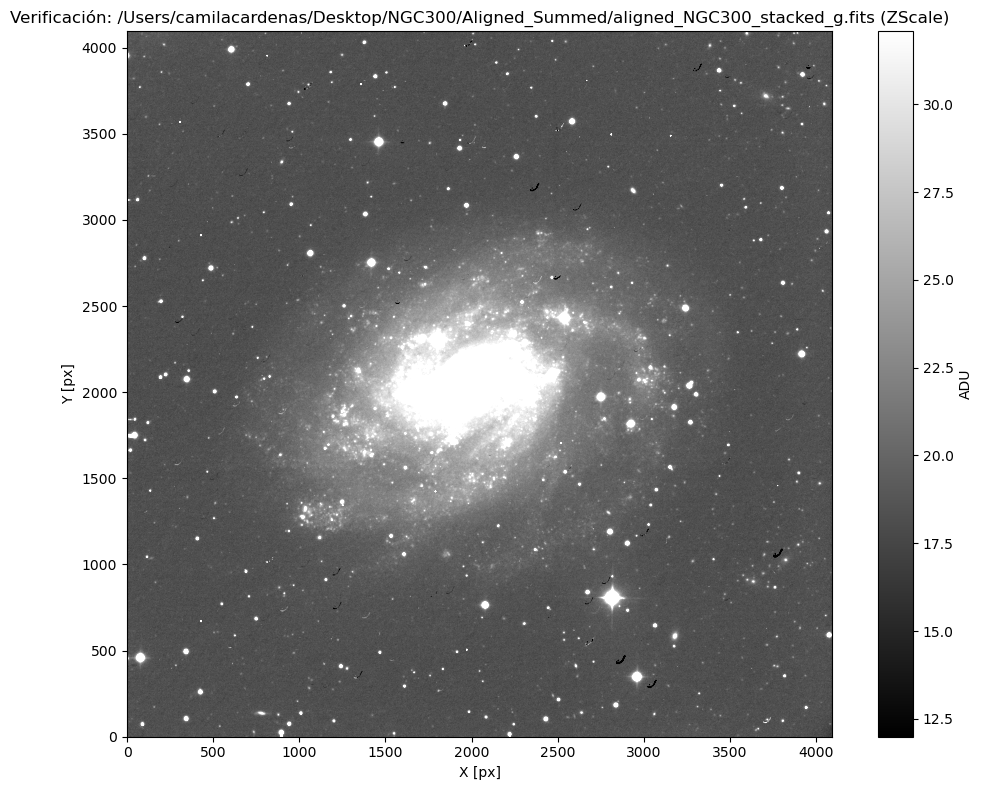

In [4]:
# Nombre del archivo
archivo = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g.fits"

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(img)

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

# # # SigmaClipping

Imagen cargada correctamente.
Corrigiendo 2199 píxeles negativos...
FITS limpio guardado en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g_CLEAN.fits
Aplicando escala ZScale para TIFF: vmin=11.99, vmax=32.08
Imagen TIFF guardada en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g_CLEAN.tiff


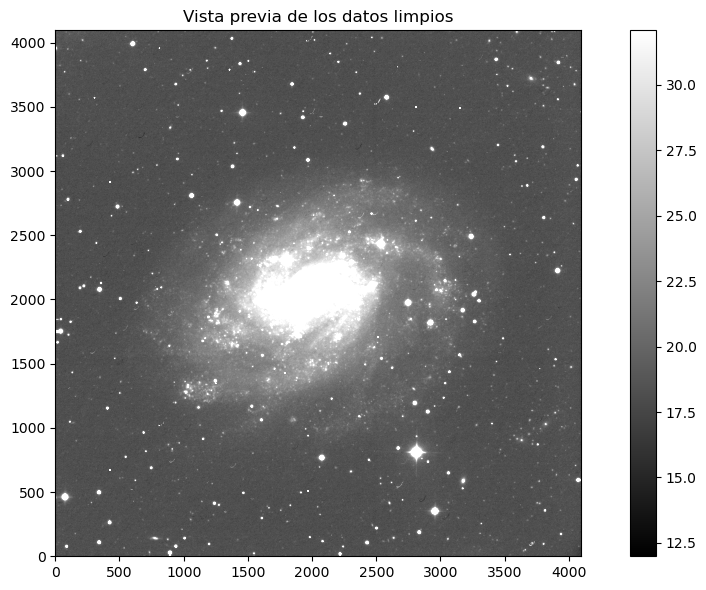

In [5]:
# RUTAS
input_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g.fits"
# Definimos dos salidas: una para el FITS limpio y otra para el TIFF
output_fits_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g_CLEAN.fits"
output_tiff_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g_CLEAN.tiff"

# 1. CARGAR IMAGEN
try:
    data = fits.getdata(input_path).astype(float)
    header = fits.getheader(input_path)
    print("Imagen cargada correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra el archivo.")
    exit()

# 2. LIMPIEZA DE PIXELES NEGATIVOS (Manchas negras)
median_val = np.median(data)
mask_bad_pixels = data < 0 
num_bad_pixels = np.sum(mask_bad_pixels)
print(f"Corrigiendo {num_bad_pixels} píxeles negativos...")

data_clean = data.copy()
data_clean[mask_bad_pixels] = median_val

# 3. GUARDAR COMO FITS (Datos científicos)
fits.writeto(output_fits_path, data_clean, header, overwrite=True)
print(f"FITS limpio guardado en: {output_fits_path}")

# --- NUEVA SECCIÓN: GUARDAR COMO TIFF ---

# 4. PREPARAR DATOS PARA TIFF (Visualización)
# Usamos ZScale para encontrar el contraste óptimo (igual que en tu gráfica)
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data_clean)

print(f"Aplicando escala ZScale para TIFF: vmin={vmin:.2f}, vmax={vmax:.2f}")

# a) Cortamos los valores extremos (Clip)
data_norm = np.clip(data_clean, vmin, vmax)

# b) Normalizamos de 0 a 1
data_norm = (data_norm - vmin) / (vmax - vmin)

# c) Convertimos a 8-bit (0 a 255) para formato de imagen estándar
# Si quieres 16-bit para edición en Photoshop, cambia 255 por 65535 y uint8 por uint16
data_8bit = (data_norm * 255).astype(np.uint8)

# d) Invertir eje Y (FITS tiene el origen abajo-izq, las imágenes TIFF arriba-izq)
data_8bit = np.flipud(data_8bit)

# 5. GUARDAR TIFF
image_tiff = Image.fromarray(data_8bit)
image_tiff.save(output_tiff_path)
print(f"Imagen TIFF guardada en: {output_tiff_path}")

# 6. VERIFICACIÓN VISUAL
plt.figure(figsize=(10, 6))
plt.title("Vista previa de los datos limpios")
plt.imshow(data_clean, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.tight_layout()
plt.show()

Imagen cargada correctamente.
Corrigiendo 1377 píxeles negativos...
FITS limpio guardado en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_i_CLEAN.fits
Aplicando escala ZScale para TIFF: vmin=33.72, vmax=60.10
Imagen TIFF guardada en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_i_CLEAN.tiff


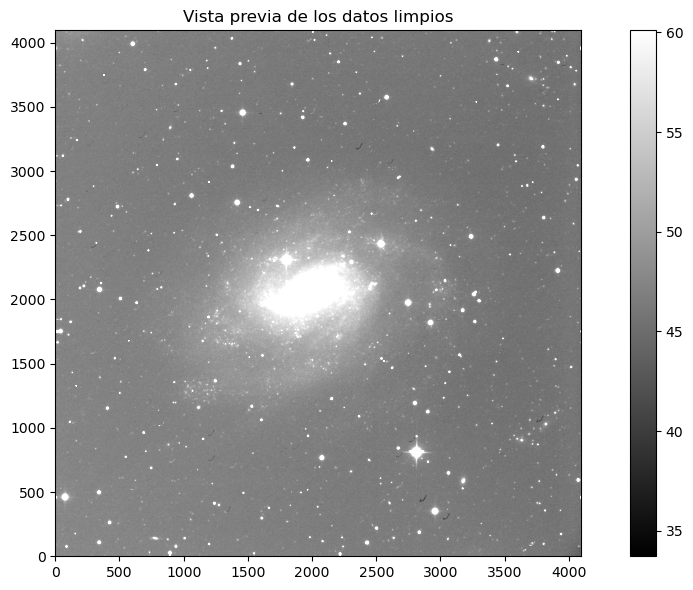

In [6]:
# RUTAS
input_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_i.fits"
# Definimos dos salidas: una para el FITS limpio y otra para el TIFF
output_fits_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_i_CLEAN.fits"
output_tiff_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_i_CLEAN.tiff"

# 1. CARGAR IMAGEN
try:
    data = fits.getdata(input_path).astype(float)
    header = fits.getheader(input_path)
    print("Imagen cargada correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra el archivo.")
    exit()

# 2. LIMPIEZA DE PIXELES NEGATIVOS (Manchas negras)
median_val = np.median(data)
mask_bad_pixels = data < 0 
num_bad_pixels = np.sum(mask_bad_pixels)
print(f"Corrigiendo {num_bad_pixels} píxeles negativos...")

data_clean = data.copy()
data_clean[mask_bad_pixels] = median_val

# 3. GUARDAR COMO FITS (Datos científicos)
fits.writeto(output_fits_path, data_clean, header, overwrite=True)
print(f"FITS limpio guardado en: {output_fits_path}")

# --- NUEVA SECCIÓN: GUARDAR COMO TIFF ---

# 4. PREPARAR DATOS PARA TIFF (Visualización)
# Usamos ZScale para encontrar el contraste óptimo (igual que en tu gráfica)
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data_clean)

print(f"Aplicando escala ZScale para TIFF: vmin={vmin:.2f}, vmax={vmax:.2f}")

# a) Cortamos los valores extremos (Clip)
data_norm = np.clip(data_clean, vmin, vmax)

# b) Normalizamos de 0 a 1
data_norm = (data_norm - vmin) / (vmax - vmin)

# c) Convertimos a 8-bit (0 a 255) para formato de imagen estándar
# Si quieres 16-bit para edición en Photoshop, cambia 255 por 65535 y uint8 por uint16
data_8bit = (data_norm * 255).astype(np.uint8)

# d) Invertir eje Y (FITS tiene el origen abajo-izq, las imágenes TIFF arriba-izq)
data_8bit = np.flipud(data_8bit)

# 5. GUARDAR TIFF
image_tiff = Image.fromarray(data_8bit)
image_tiff.save(output_tiff_path)
print(f"Imagen TIFF guardada en: {output_tiff_path}")

# 6. VERIFICACIÓN VISUAL
plt.figure(figsize=(10, 6))
plt.title("Vista previa de los datos limpios")
plt.imshow(data_clean, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.tight_layout()
plt.show()

Imagen cargada correctamente.
Corrigiendo 1371 píxeles negativos...
FITS limpio guardado en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_r_CLEAN.fits
Aplicando escala ZScale para TIFF: vmin=33.31, vmax=52.79
Imagen TIFF guardada en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_r_CLEAN.tiff


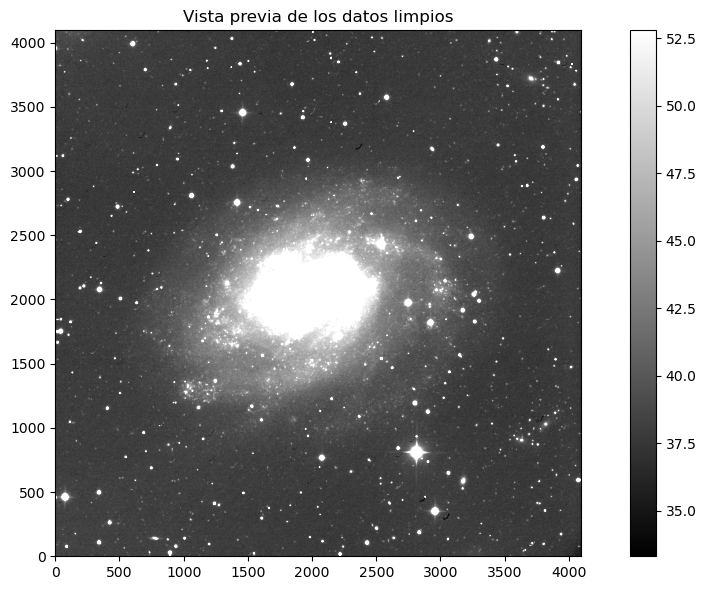

In [7]:
# RUTAS
input_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_r.fits"
# Definimos dos salidas: una para el FITS limpio y otra para el TIFF
output_fits_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_r_CLEAN.fits"
output_tiff_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_r_CLEAN.tiff"

# 1. CARGAR IMAGEN
try:
    data = fits.getdata(input_path).astype(float)
    header = fits.getheader(input_path)
    print("Imagen cargada correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra el archivo.")
    exit()

# 2. LIMPIEZA DE PIXELES NEGATIVOS (Manchas negras)
median_val = np.median(data)
mask_bad_pixels = data < 0 
num_bad_pixels = np.sum(mask_bad_pixels)
print(f"Corrigiendo {num_bad_pixels} píxeles negativos...")

data_clean = data.copy()
data_clean[mask_bad_pixels] = median_val

# 3. GUARDAR COMO FITS (Datos científicos)
fits.writeto(output_fits_path, data_clean, header, overwrite=True)
print(f"FITS limpio guardado en: {output_fits_path}")

# --- NUEVA SECCIÓN: GUARDAR COMO TIFF ---

# 4. PREPARAR DATOS PARA TIFF (Visualización)
# Usamos ZScale para encontrar el contraste óptimo (igual que en tu gráfica)
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data_clean)

print(f"Aplicando escala ZScale para TIFF: vmin={vmin:.2f}, vmax={vmax:.2f}")

# a) Cortamos los valores extremos (Clip)
data_norm = np.clip(data_clean, vmin, vmax)

# b) Normalizamos de 0 a 1
data_norm = (data_norm - vmin) / (vmax - vmin)

# c) Convertimos a 8-bit (0 a 255) para formato de imagen estándar
# Si quieres 16-bit para edición en Photoshop, cambia 255 por 65535 y uint8 por uint16
data_8bit = (data_norm * 255).astype(np.uint8)

# d) Invertir eje Y (FITS tiene el origen abajo-izq, las imágenes TIFF arriba-izq)
data_8bit = np.flipud(data_8bit)

# 5. GUARDAR TIFF
image_tiff = Image.fromarray(data_8bit)
image_tiff.save(output_tiff_path)
print(f"Imagen TIFF guardada en: {output_tiff_path}")

# 6. VERIFICACIÓN VISUAL
plt.figure(figsize=(10, 6))
plt.title("Vista previa de los datos limpios")
plt.imshow(data_clean, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.tight_layout()
plt.show()

Imagen cargada correctamente.
Corrigiendo 8573984 píxeles negativos...
FITS limpio guardado en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_u_CLEAN.fits
Aplicando escala ZScale para TIFF: vmin=-0.08, vmax=7.08
Imagen TIFF guardada en: /Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_u_CLEAN.tiff


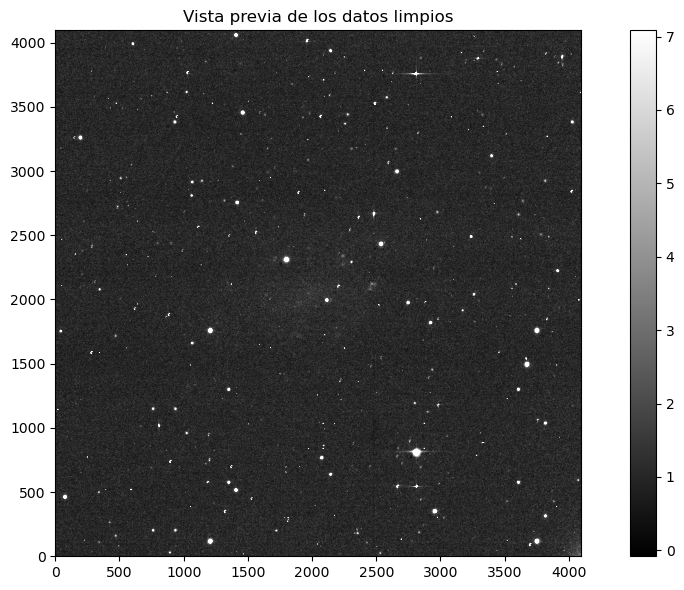

In [8]:
# RUTAS
input_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_u.fits"
# Definimos dos salidas: una para el FITS limpio y otra para el TIFF
output_fits_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_u_CLEAN.fits"
output_tiff_path = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_u_CLEAN.tiff"

# 1. CARGAR IMAGEN
try:
    data = fits.getdata(input_path).astype(float)
    header = fits.getheader(input_path)
    print("Imagen cargada correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra el archivo.")
    exit()

# 2. LIMPIEZA DE PIXELES NEGATIVOS (Manchas negras)
median_val = np.median(data)
mask_bad_pixels = data < 0 
num_bad_pixels = np.sum(mask_bad_pixels)
print(f"Corrigiendo {num_bad_pixels} píxeles negativos...")

data_clean = data.copy()
data_clean[mask_bad_pixels] = median_val

# 3. GUARDAR COMO FITS (Datos científicos)
fits.writeto(output_fits_path, data_clean, header, overwrite=True)
print(f"FITS limpio guardado en: {output_fits_path}")

# --- NUEVA SECCIÓN: GUARDAR COMO TIFF ---

# 4. PREPARAR DATOS PARA TIFF (Visualización)
# Usamos ZScale para encontrar el contraste óptimo (igual que en tu gráfica)
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data_clean)

print(f"Aplicando escala ZScale para TIFF: vmin={vmin:.2f}, vmax={vmax:.2f}")

# a) Cortamos los valores extremos (Clip)
data_norm = np.clip(data_clean, vmin, vmax)

# b) Normalizamos de 0 a 1
data_norm = (data_norm - vmin) / (vmax - vmin)

# c) Convertimos a 8-bit (0 a 255) para formato de imagen estándar
# Si quieres 16-bit para edición en Photoshop, cambia 255 por 65535 y uint8 por uint16
data_8bit = (data_norm * 255).astype(np.uint8)

# d) Invertir eje Y (FITS tiene el origen abajo-izq, las imágenes TIFF arriba-izq)
data_8bit = np.flipud(data_8bit)

# 5. GUARDAR TIFF
image_tiff = Image.fromarray(data_8bit)
image_tiff.save(output_tiff_path)
print(f"Imagen TIFF guardada en: {output_tiff_path}")

# 6. VERIFICACIÓN VISUAL
plt.figure(figsize=(10, 6))
plt.title("Vista previa de los datos limpios")
plt.imshow(data_clean, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.tight_layout()
plt.show()

### Informe 

### Bias Frame

Archivos Bias encontrados: 101


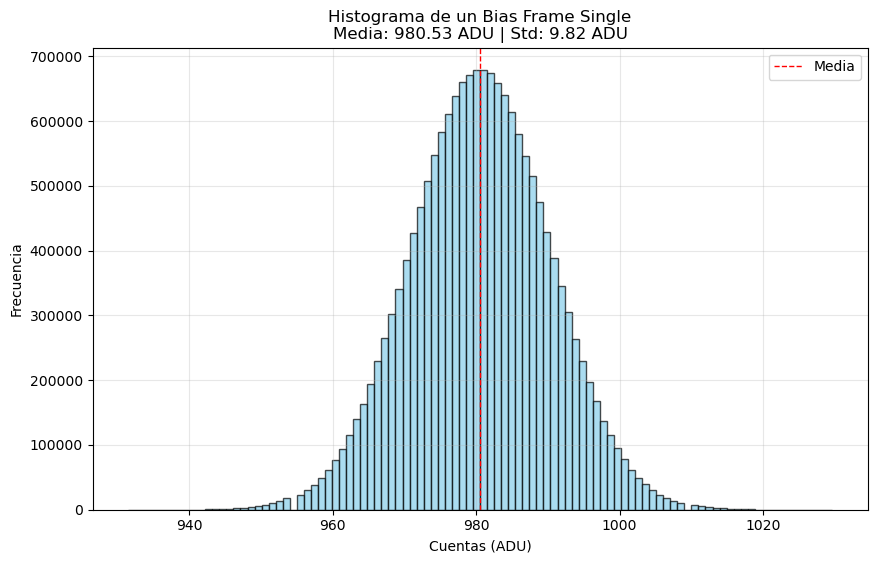


Calculando RON usando el método de diferencia en 10 pares...
Readout Noise (RON) calculado: 9.7987 ADU

Generando Master Bias (esto puede tardar un poco)...
Master Bias (Mean y Median) guardados.

--- Comparación de Ruido Residual ---
Ruido en 1 frame (Single):      9.8242 ADU
Ruido en Master Mean (101 img): 1.3042 ADU
Ruido en Master Median (101 img):1.4180 ADU
Predicción teórica (Sigma/sqrt(N)): 0.9775 ADU


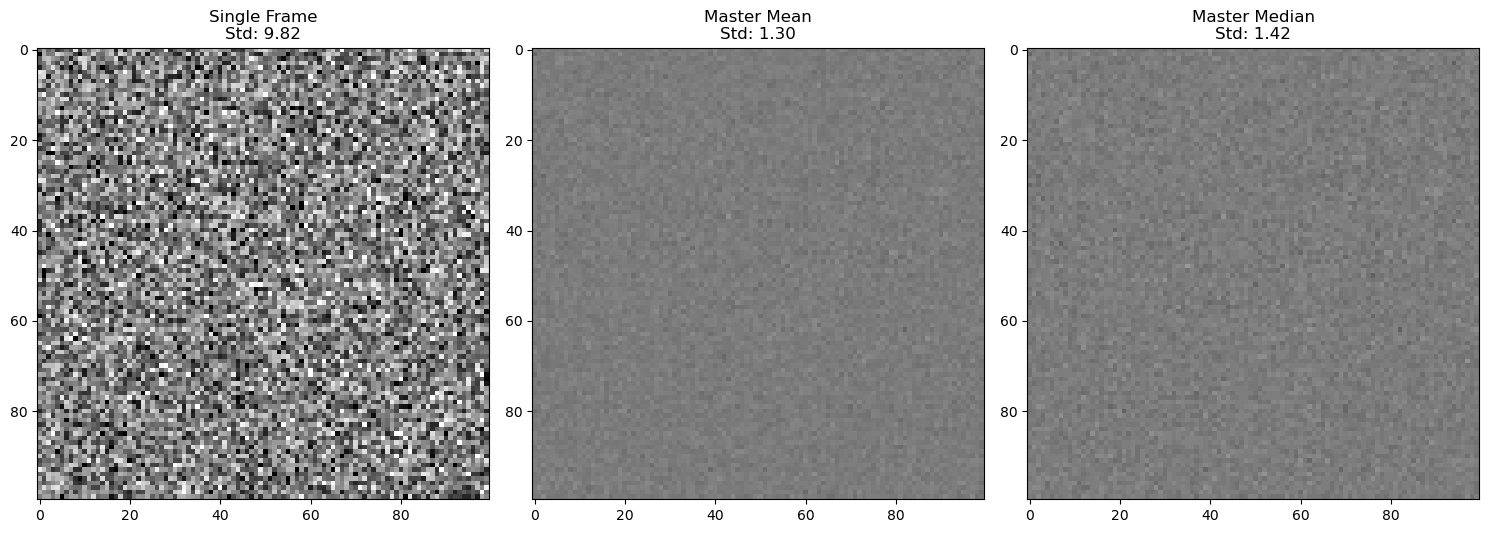

In [5]:
base_path = "./"
bias_folder = os.path.join(base_path, "Bias")

def get_fits_files(folder):
    files = []
    if not os.path.exists(folder): return []
    for f in sorted(os.listdir(folder)):
        if f.lower().startswith("bias") and f.lower().endswith(".fit"):
            files.append(os.path.join(folder, f))
    return files

bias_files = get_fits_files(bias_folder)
if len(bias_files) < 2:
    raise ValueError("Necesitas al menos 2 archivos Bias para calcular el RON.")

print(f"Archivos Bias encontrados: {len(bias_files)}")


def plot_bias_histogram(files):
    # Cargamos el primer archivo
    first_bias = fits.getdata(files[0]).astype(float)
    
    # Aplanamos la matriz a 1D para el histograma
    pixels = first_bias.flatten()
    
    mean_val = np.mean(pixels)
    std_val = np.std(pixels)
    
    plt.figure(figsize=(10, 6))
    plt.hist(pixels, bins=100, range=(mean_val - 5*std_val, mean_val + 5*std_val), 
             color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"Histograma de un Bias Frame Single\nMedia: {mean_val:.2f} ADU | Std: {std_val:.2f} ADU")
    plt.xlabel("Cuentas (ADU)")
    plt.ylabel("Frecuencia")
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label='Media')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def calculate_ron(files):
    ron_values = []
    
    # Calculamos el RON usando pares consecutivos para tener una estadística robusta
    # Usamos hasta 10 pares para no tardar mucho, o todos si son pocos
    num_pairs = min(len(files) - 1, 10)
    
    print(f"\nCalculando RON usando el método de diferencia en {num_pairs} pares...")
    
    for i in range(num_pairs):
        b1 = fits.getdata(files[i]).astype(float)
        b2 = fits.getdata(files[i+1]).astype(float)
        
        # Diferencia
        diff_image = b1 - b2
        
        # Desviación estándar de la diferencia
        sigma_diff = np.std(diff_image)
        
        # Aplicamos la fórmula de la pista
        ron_i = sigma_diff / np.sqrt(2)
        ron_values.append(ron_i)
        
    avg_ron = np.mean(ron_values)
    print(f"Readout Noise (RON) calculado: {avg_ron:.4f} ADU")
    return avg_ron


def create_masters(files):
    print("\nGenerando Master Bias (esto puede tardar un poco)...")
    stack = []
    for f in files:
        stack.append(fits.getdata(f).astype(float))
    
    stack = np.array(stack)
    
    # Promedio (Mean)
    master_mean = np.mean(stack, axis=0)
    
    # Mediana (Median)
    master_median = np.median(stack, axis=0)
    
    # Guardamos
    fits.writeto("Master_Bias_Mean.fits", master_mean, overwrite=True)
    fits.writeto("Master_Bias_Median.fits", master_median, overwrite=True)
    
    print("Master Bias (Mean y Median) guardados.")
    return master_mean, master_median


def compare_residual_noise(single_file, master_mean, master_median, n_frames):
    single = fits.getdata(single_file).astype(float)
    
    sigma_single = np.std(single)
    sigma_mean = np.std(master_mean)
    sigma_median = np.std(master_median)
    
    theoretical_reduction = sigma_single / np.sqrt(n_frames)
    
    print("\n--- Comparación de Ruido Residual ---")
    print(f"Ruido en 1 frame (Single):      {sigma_single:.4f} ADU")
    print(f"Ruido en Master Mean ({n_frames} img): {sigma_mean:.4f} ADU")
    print(f"Ruido en Master Median ({n_frames} img):{sigma_median:.4f} ADU")
    print(f"Predicción teórica (Sigma/sqrt(N)): {theoretical_reduction:.4f} ADU")
    
    # Plot comparativo rápido (zoom al centro)
    h, w = single.shape
    cx, cy = w//2, h//2
    size = 50
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Usamos mismos límites de visualización para comparar "grano"
    vmin, vmax = np.percentile(single, [1, 99])
    
    ax[0].imshow(single[cy-size:cy+size, cx-size:cx+size], cmap='gray', vmin=vmin, vmax=vmax)
    ax[0].set_title(f"Single Frame\nStd: {sigma_single:.2f}")
    
    ax[1].imshow(master_mean[cy-size:cy+size, cx-size:cx+size], cmap='gray', vmin=vmin, vmax=vmax)
    ax[1].set_title(f"Master Mean\nStd: {sigma_mean:.2f}")
    
    ax[2].imshow(master_median[cy-size:cy+size, cx-size:cx+size], cmap='gray', vmin=vmin, vmax=vmax)
    ax[2].set_title(f"Master Median\nStd: {sigma_median:.2f}")
    
    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
if __name__ == "__main__":
    # 1. Histograma
    plot_bias_histogram(bias_files)
    
    # 2. RON
    ron = calculate_ron(bias_files)
    
    # 3. Masters
    m_mean, m_median = create_masters(bias_files)
    
    # 4. Comparación
    compare_residual_noise(bias_files[0], m_mean, m_median, len(bias_files))

### Dark frame

--- Cargando Masters ---
Master bias (0s) creado con 101 frames.
Master dark_flat (5s) creado con 51 frames.
Master dark (120s) creado con 22 frames.

--- Análisis 1: Dark (120s) vs Bias ---

Comparación: Master Dark (120s) vs Master Bias
  Master Dark (120s): Media=984.04, Std=88.55
  Master Bias: Media=979.83, Std=1.30
  Diferencia promedio (Master Dark (120s) - Master Bias): 4.2121 ADU

--- Análisis 2: Dark Flat (5s) vs Bias ---

Comparación: Master Dark Flat (5s) vs Master Bias
  Master Dark Flat (5s): Media=981.74, Std=11.78
  Master Bias: Media=979.83, Std=1.30
  Diferencia promedio (Master Dark Flat (5s) - Master Bias): 1.9128 ADU

--- Análisis 3: Cálculo de Ganancia (Gain) ---
Nivel medio en el centro (De-biased): 39145.93 ADU
Varianza del ruido (Shot noise): 21372.61
FACTOR DE CONVERSIÓN ESTIMADO (GAIN): 1.832 e-/ADU


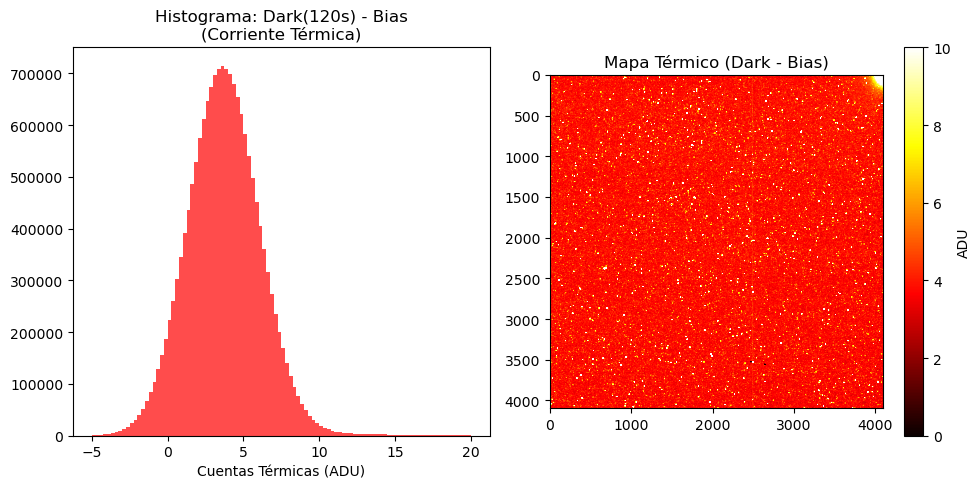

In [6]:
# --- RUTAS ---
base_path = "./"

# Función para cargar Master si existe, o generarlo al vuelo (simplificado)
def load_or_create_master(folder, prefix, exposure_label=""):
    files = [os.path.join(folder, f) for f in sorted(os.listdir(folder)) 
             if f.startswith(prefix) and f.endswith('.fit')]
    
    if not files:
        print(f"Advertencia: No se encontraron archivos en {folder}")
        return None
    
    # Cargamos para estadística
    stack = [fits.getdata(f).astype(float) for f in files]
    master = np.mean(stack, axis=0)
    print(f"Master {prefix} ({exposure_label}) creado con {len(files)} frames.")
    return master

# --- 1. CARGAR DATOS ---
print("--- Cargando Masters ---")
# Bias (0 seg)
master_bias = load_or_create_master(os.path.join(base_path, "Bias"), "bias", "0s")

# Dark Flat (4s o 5s) - Usaremos i_u (5s) como ejemplo representativo
master_dark_flat = load_or_create_master(os.path.join(base_path, "Dark_flat", "i_u"), "dark_flat", "5s")

# Dark Largo (120s)
master_dark_long = load_or_create_master(os.path.join(base_path, "Dark"), "dark", "120s")

# --- 2. COMPARACIÓN DE DARKS Y BIAS ---
def compare_statistics(name1, img1, name2, img2):
    if img1 is None or img2 is None: return
    
    mean1, std1 = np.mean(img1), np.std(img1)
    mean2, std2 = np.mean(img2), np.std(img2)
    
    diff = img1 - img2
    mean_diff = np.mean(diff)
    
    print(f"\nComparación: {name1} vs {name2}")
    print(f"  {name1}: Media={mean1:.2f}, Std={std1:.2f}")
    print(f"  {name2}: Media={mean2:.2f}, Std={std2:.2f}")
    print(f"  Diferencia promedio ({name1} - {name2}): {mean_diff:.4f} ADU")
    
    return diff

print("\n--- Análisis 1: Dark (120s) vs Bias ---")
diff_long = compare_statistics("Master Dark (120s)", master_dark_long, "Master Bias", master_bias)

print("\n--- Análisis 2: Dark Flat (5s) vs Bias ---")
diff_short = compare_statistics("Master Dark Flat (5s)", master_dark_flat, "Master Bias", master_bias)

# --- 3. CÁLCULO DE GANANCIA (CONVERSION FACTOR) ---
# Usaremos 2 Flat frames del mismo filtro (ej. Green) para eliminar el patrón fijo
print("\n--- Análisis 3: Cálculo de Ganancia (Gain) ---")

flat_folder_g = os.path.join(base_path, "Flat", "g")
flat_files = [os.path.join(flat_folder_g, f) for f in sorted(os.listdir(flat_folder_g)) if f.endswith('.fit')]

if len(flat_files) >= 2 and master_bias is not None:
    # Cargar dos flats
    f1_raw = fits.getdata(flat_files[0]).astype(float)
    f2_raw = fits.getdata(flat_files[1]).astype(float)
    
    # Restar Bias (De-biased)
    f1 = f1_raw - master_bias
    f2 = f2_raw - master_bias
    
    # Seleccionar porción central (ej. 200x200 px en el centro)
    h, w = f1.shape
    cx, cy = w//2, h//2
    size = 100 # Radio (total 200x200)
    
    box1 = f1[cy-size:cy+size, cx-size:cx+size]
    box2 = f2[cy-size:cy+size, cx-size:cx+size]
    
    # Media de la señal (en ADU)
    mean_signal = (np.mean(box1) + np.mean(box2)) / 2.0
    
    # Varianza de la diferencia (elimina patrón fijo, queda solo ruido de disparo * 2)
    # Var(F1 - F2) = Var(F1) + Var(F2) = 2 * Var(ShotNoise)
    var_diff = np.var(box1 - box2)
    var_shot_adu = var_diff / 2.0
    
    # Fórmula: Gain = Mean / Variance (Asumiendo estadística de Poisson)
    # Electrones = Gain * ADU
    # Poisson: Var(e-) = Mean(e-)  ->  Gain^2 * Var(ADU) = Gain * Mean(ADU)
    # Gain = Mean(ADU) / Var(ADU)
    
    gain = mean_signal / var_shot_adu
    
    print(f"Nivel medio en el centro (De-biased): {mean_signal:.2f} ADU")
    print(f"Varianza del ruido (Shot noise): {var_shot_adu:.2f}")
    print(f"FACTOR DE CONVERSIÓN ESTIMADO (GAIN): {gain:.3f} e-/ADU")
    
else:
    print("No se encontraron suficientes Flats filtro G o falta el Master Bias.")

# --- VISUALIZACIÓN ---
if diff_long is not None:
    plt.figure(figsize=(10, 5))
    
    # Histograma de la corriente térmica
    plt.subplot(1, 2, 1)
    plt.hist(diff_long.flatten(), bins=100, range=(-5, 20), color='red', alpha=0.7)
    plt.title("Histograma: Dark(120s) - Bias\n(Corriente Térmica)")
    plt.xlabel("Cuentas Térmicas (ADU)")
    
    # Imagen de pixeles calientes
    plt.subplot(1, 2, 2)
    plt.imshow(diff_long, vmin=0, vmax=10, cmap='hot')
    plt.title("Mapa Térmico (Dark - Bias)")
    plt.colorbar(label='ADU')
    
    plt.tight_layout()
    plt.show()

### Flat Frame 

Analizando 22 flats del filtro u...
  > Variación en filtro u: 34.38%
Analizando 11 flats del filtro g...
  > Variación en filtro g: 34.03%
Analizando 11 flats del filtro r...
  > Variación en filtro r: 37.80%
Analizando 11 flats del filtro i...
  > Variación en filtro i: 47.29%


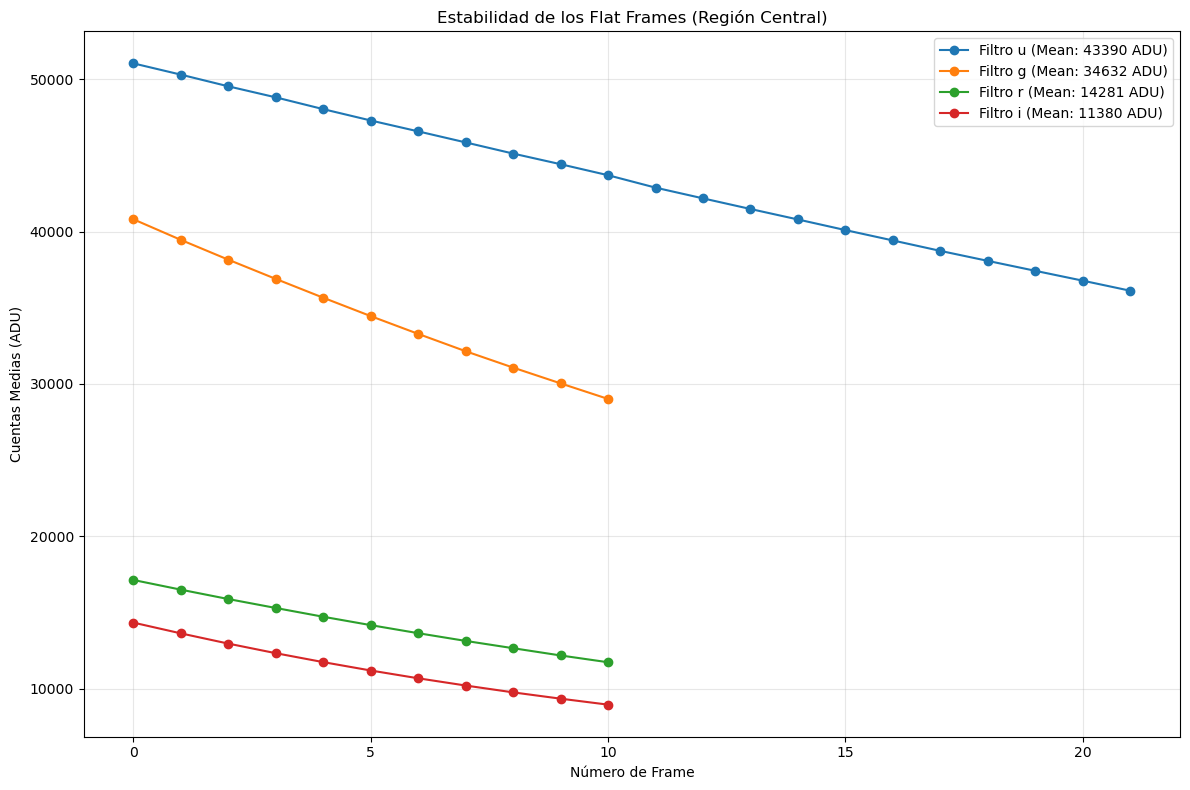

In [8]:
# --- CONFIGURACIÓN ---
base_path = "./"
flat_base_folder = os.path.join(base_path, "Flat")
filters = ['u', 'g', 'r', 'i']

def analyze_flat_stability(filters, base_folder):
    plt.figure(figsize=(12, 8))
    
    for filt in filters:
        folder = os.path.join(base_folder, filt)
        if not os.path.exists(folder):
            print(f"Saltando filtro {filt} (carpeta no encontrada)")
            continue
            
        files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.fit')])
        if not files: continue
        
        means = []
        indices = []
        
        print(f"Analizando {len(files)} flats del filtro {filt}...")
        
        for i, f in enumerate(files):
            data = fits.getdata(f).astype(float)
            
            # Recorte central (para evitar bordes oscuros/vignetting en la medida)
            h, w = data.shape
            cx, cy = w//2, h//2
            size = 100 # Caja de 200x200
            center_region = data[cy-size:cy+size, cx-size:cx+size]
            
            means.append(np.mean(center_region))
            indices.append(i)
            
        # Normalizar a la primera imagen para comparar variaciones relativas
        means = np.array(means)
        relative_means = means / means[0]
        
        # Graficar
        plt.plot(indices, means, '-o', label=f'Filtro {filt} (Mean: {np.mean(means):.0f} ADU)')
        
        # Calcular variación
        variation = (np.max(means) - np.min(means)) / np.mean(means) * 100
        print(f"  > Variación en filtro {filt}: {variation:.2f}%")

    plt.title("Estabilidad de los Flat Frames (Región Central)")
    plt.xlabel("Número de Frame")
    plt.ylabel("Cuentas Medias (ADU)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_flat_stability(filters, flat_base_folder)

### Procesamiento

In [26]:
import os
import numpy as np
from astropy.io import fits
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

# Base route
base_path = "./"

# Función recursiva para encontrar archivos FITS en subcarpetas
def get_fits_files(folder_path, prefix=""):
    files = []
    if not os.path.exists(folder_path):
        return []
    for root, dirs, filenames in os.walk(folder_path):
        for f in filenames:
            if f.lower().startswith(prefix.lower()) and f.lower().endswith(('.fits', '.fit')):
                files.append(os.path.join(root, f))
    return sorted(files)

# CARGA DE ARCHIVOS 
print("Cargando archivos...")

bias_files = get_fits_files(os.path.join(base_path, "Bias"), "bias")
dark_files = get_fits_files(os.path.join(base_path, "Dark"), "dark")
dark_flat_iu_files = get_fits_files(os.path.join(base_path, "Dark_flat", "i_u"), "dark_flat")
dark_flat_gr_files = get_fits_files(os.path.join(base_path, "Dark_flat", "g_r"), "dark_flat")

flat_files_u = get_fits_files(os.path.join(base_path, "Flat", "u"), "flat")
flat_files_i = get_fits_files(os.path.join(base_path, "Flat", "i"), "flat")
flat_files_g = get_fits_files(os.path.join(base_path, "Flat", "g"), "flat")
flat_files_r = get_fits_files(os.path.join(base_path, "Flat", "r"), "flat")

light_files_u = get_fits_files(os.path.join(base_path, "Light", "u"), "NGC300")
light_files_i = get_fits_files(os.path.join(base_path, "Light", "i"), "NGC300")
light_files_g = get_fits_files(os.path.join(base_path, "Light", "g"), "NGC300")
light_files_r = get_fits_files(os.path.join(base_path, "Light", "r"), "NGC300")

if not bias_files: raise ValueError("No se encontraron archivos Bias.")
if not dark_files: print("Warning: No valid dark files found for lights.")

light_by_filter = {
    "u": light_files_u,
    "i": light_files_i,
    "g": light_files_g,
    "r": light_files_r
}

aligned_dir = os.path.join(base_path, "Aligned")
processed_dir = os.path.join(base_path, "Processed")
summed_dir = os.path.join(base_path, "Summed")

os.makedirs(aligned_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)
os.makedirs(summed_dir, exist_ok=True)

# FUNCIONES DE PROCESAMIENTO

def combine_images(file_list):
    """Combina imágenes usando la MEDIA (Mean). Validado por tus resultados de Bias."""
    data_stack = []
    for f in file_list:
        try:
            data = fits.getdata(f).astype(float)
            data_stack.append(data)
        except Exception as e:
            print(f"Error al leer {f}: {str(e)}")
            continue
    
    if not data_stack:
        raise ValueError("No images to combine")
    return np.mean(data_stack, axis=0)

# CREACIÓN DE MASTERS 

# A. Master Bias
print("Creando Master Bias...")
master_bias = combine_images(bias_files)
fits.writeto(os.path.join(base_path, "master_bias.fits"), master_bias, overwrite=True)

# B. Master Dark 
print("Creando Master Dark (120s)...")
if dark_files:
    master_dark = combine_images(dark_files) 
    fits.writeto(os.path.join(base_path, "master_dark_120s.fits"), master_dark, overwrite=True)
else:
    master_dark = np.zeros_like(master_bias)

# C. Master Dark Flats
print("Creando Master Dark Flats...")
master_dark_flat_iu = combine_images(dark_flat_iu_files) if dark_flat_iu_files else np.zeros_like(master_bias)
master_dark_flat_gr = combine_images(dark_flat_gr_files) if dark_flat_gr_files else np.zeros_like(master_bias)

# D. Master Flats (CORREGIDO: Normalización Individual)
# ---------------------------------------------------------
# CORRECCIÓN IMPORTANTE BASADA EN TUS GRÁFICOS:
# Como la luz de tus flats varió un 40%, debemos normalizar cada frame 
# individualmente ANTES de combinarlos.
# ---------------------------------------------------------

master_flats = {}

flat_config = [
    ("u", flat_files_u, master_dark_flat_iu),
    ("i", flat_files_i, master_dark_flat_iu),
    ("g", flat_files_g, master_dark_flat_gr),
    ("r", flat_files_r, master_dark_flat_gr)
]

print("Creando Master Flats (Estrategia: Normalización Individual)...")

for filt, files, dark_flat_ref in flat_config:
    if not files:
        print(f"Warning: No flats found for filter {filt}")
        continue
    
    try:
        normalized_stack = []
        
        for f in files:
            # 1. Cargar Flat individual
            data = fits.getdata(f).astype(float)
            
            # 2. Corregir Bias/DarkFlat primero
            corrected = data - dark_flat_ref
            
            # 3. Calcular la media de ESTE frame específico
            mean_val = np.mean(corrected)
            
            # 4. Normalizar este frame para que su media sea 1.0
            # Esto elimina el efecto de la lámpara apagándose
            normalized_frame = corrected / mean_val
            
            normalized_stack.append(normalized_frame)
        
        # 5. Ahora sí podemos combinar (Promediar los frames ya normalizados)
        master_flat_final = np.mean(normalized_stack, axis=0)
        
        # Guardar
        master_flats[filt] = master_flat_final
        fits.writeto(os.path.join(base_path, f"master_flat_{filt}.fits"), master_flat_final, overwrite=True)
        print(f"Master Flat {filt} creado correctamente.")
        
    except Exception as e:
        print(f"Error processing flats for filter {filt}: {str(e)}")

# REDUCCIÓN DE IMÁGENES CIENTÍFICAS 

def reduce_light(path, filt):
    try:
        data = fits.getdata(path).astype(float)
        if filt not in master_flats:
            raise ValueError(f"No master flat for filter {filt}")
            
        # (Light - Dark) / MasterFlat
        reduced = (data - master_dark) / master_flats[filt]
        return reduced
    except Exception as e:
        print(f"Error reducing {path}: {str(e)}")
        return None

# ALINEACIÓN 

def enhanced_align_images(image_list, reference_image=None, upsample_factor=10):
    if not image_list: return []
    aligned = []
    
    if reference_image is None:
        ref_image = image_list[0]
        aligned.append(ref_image)
        images_to_align = image_list[1:]
    else:
        ref_image = reference_image
        images_to_align = image_list
    
    crop_pixels = 50
    h, w = ref_image.shape
    ref_cropped = ref_image[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
    
    for img in images_to_align:
        try:
            img_cropped = img[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
            shift_val, error, diffphase = phase_cross_correlation(
                ref_cropped, img_cropped, upsample_factor=upsample_factor, normalization=None
            )
            shifted = shift(img, shift_val, mode='reflect')
            aligned.append(shifted)
            print(f"Calculated displacement: {shift_val}")
        except Exception as e:
            print(f"Error aligning image: {str(e)}")
            continue
    return aligned if reference_image is None else aligned

# EJECUCIÓN 

reference_image = None
# Procesar r e i primero (suelen tener mejor señal para alinear)
for filt in ["r", "i"]:
    files = light_by_filter.get(filt, [])
    if files:
        print(f"\nProcesando filtro {filt} con {len(files)} imágenes...")
        reduced_imgs = []
        for f in files:
            reduced = reduce_light(f, filt)
            if reduced is not None: reduced_imgs.append(reduced)
        
        if reduced_imgs:
            aligned_imgs = enhanced_align_images(reduced_imgs, upsample_factor=20)
            for idx, img in enumerate(aligned_imgs):
                out_name = os.path.join(aligned_dir, f"aligned_NGC300_{filt}_{idx+1:03d}.fits")
                fits.writeto(out_name, img, overwrite=True)
            if reference_image is None and aligned_imgs:
                reference_image = aligned_imgs[0]

# Procesar g y u
for filt in ["g", "u"]:
    files = light_by_filter.get(filt, [])
    if files:
        print(f"\nProcesando filtro {filt} usando referencia r/i...")
        reduced_imgs = []
        for f in files:
            reduced = reduce_light(f, filt)
            if reduced is not None: reduced_imgs.append(reduced)
        
        if reduced_imgs:
            aligned_imgs = enhanced_align_images(reduced_imgs, reference_image=reference_image, upsample_factor=20) if reference_image is not None else enhanced_align_images(reduced_imgs, upsample_factor=20)
            for idx, img in enumerate(aligned_imgs):
                out_name = os.path.join(aligned_dir, f"aligned_NGC300_{filt}_{idx+1:03d}.fits")
                fits.writeto(out_name, img, overwrite=True)

# STACKING 

print("\nGenerando imágenes finales (Stacking)...")
for filt in ["g", "r", "i", "u"]:
    aligned_files = get_fits_files(aligned_dir, f"aligned_NGC300_{filt}")
    if aligned_files:
        stack = []
        for f in aligned_files:
            stack.append(fits.getdata(f).astype(float))
        
        # Mantenemos MEAN porque tus Bias mostraron que reduce bien el ruido
        summed = np.mean(stack, axis=0)
        
        out_path = os.path.join(summed_dir, f"NGC300_stacked_{filt}.fits")
        fits.writeto(out_path, summed, overwrite=True)
        print(f"Guardado: {out_path}")
    else:
        print(f"No hay imágenes alineadas para filtro {filt}")

print("\nProceso completado.")

Cargando archivos...
Creando Master Bias...



KeyboardInterrupt



In [ ]:
# Base path
base_path = "./"
summed_dir = os.path.join(base_path, "Summed")
aligned_summed_dir = os.path.join(base_path, "Aligned_Summed")

# Create output folder if it doesn't exist
os.makedirs(aligned_summed_dir, exist_ok=True)

# Load the stacked images
def load_stacked_images():
    # Definimos los nombres generados en el paso anterior (NGC300)
    # Incluimos el filtro 'u' que faltaba en el snippet original
    stacked_files = {
        'u': os.path.join(summed_dir, "NGC300_stacked_u.fits"),
        'g': os.path.join(summed_dir, "NGC300_stacked_g.fits"),
        'r': os.path.join(summed_dir, "NGC300_stacked_r.fits"),
        'i': os.path.join(summed_dir, "NGC300_stacked_i.fits")
    }
    
    images = {}
    for filt, path in stacked_files.items():
        if os.path.exists(path):
            print(f"Loading {filt}: {path}")
            images[filt] = fits.getdata(path).astype(float)
        else:
            print(f"Warning: File not found for filter {filt}: {path}")
    
    if not images:
        raise FileNotFoundError("No stacked images found in Summed directory.")
        
    return images

# Align images using chi2_shift
def align_with_chi2(images):
    # Check if reference 'r' exists, otherwise pick the first available
    ref_filter = 'r'
    if ref_filter not in images:
        ref_filter = list(images.keys())[0]
        print(f"Warning: Reference filter 'r' not found. Using '{ref_filter}' instead.")
    
    reference = images[ref_filter]
    aligned = {ref_filter: reference}
    
    # Parameters for chi2_shift
    noise_level = np.std(reference)  # Estimate of noise level
    upsample_factor = 'auto' 
    
    print(f"\nStarting alignment with chi2_shift (Reference: {ref_filter})...")
    
    # Iterate over all other filters
    for filt, img in images.items():
        if filt == ref_filter:
            continue # Skip reference
            
        print(f"Aligning filter {filt}...")
        try:
            # Calculate shift
            xoff, yoff, exoff, eyoff = chi2_shift(
                reference, img, noise_level,
                return_error=True, upsample_factor=upsample_factor
            )
            
            # Apply shift (-y, -x ordering is typical for numpy array shifts vs image coords)
            aligned[filt] = img_shift.shiftnd(img, (-yoff, -xoff))
            
            print(f"Displacement {filt}: x={xoff:.2f} ± {exoff:.2f}, y={yoff:.2f} ± {eyoff:.2f}")
        except Exception as e:
            print(f"Error aligning {filt}: {e}. Keeping original.")
            aligned[filt] = img
    
    return aligned

# Save aligned images
def save_aligned_images(aligned_images):
    for filt, img in aligned_images.items():
        # Mantenemos convención de nombres clara
        output_filename = f"aligned_NGC300_stacked_{filt}.fits"
        output_path = os.path.join(aligned_summed_dir, output_filename)
        
        fits.writeto(output_path, img, overwrite=True)
        print(f"Aligned image {filt} saved to: {output_path}")

# Main process
def main():
    try:
        # Load images
        print("--- Loading Stacked Images ---")
        images = load_stacked_images()
        
        # Align images
        aligned_images = align_with_chi2(images)
        
        # Save results
        print("\n--- Saving Aligned Images ---")
        save_aligned_images(aligned_images)
        
        print("\nAlignment completed successfully.")
    except Exception as e:
        print(f"\nCritical Error during the process: {str(e)}")

if __name__ == "__main__":
    main()

### Deconvolution

In [13]:
# Rutas (basadas en tu código anterior)
base_path = "./"
aligned_dir = os.path.join(base_path, "Aligned_Summed")
deconv_dir = os.path.join(base_path, "Deconvolved")

os.makedirs(deconv_dir, exist_ok=True)

# 1. Función para crear una PSF Gaussiana Sintética
# El documento sugiere usar estrellas no saturadas para ajustar una Gaussiana[cite: 40, 41].
# Aquí creamos una PSF teórica promedio.
def make_gaussian_psf(size=21, sigma=2.0):
    """
    Crea una PSF Gaussiana 2D normalizada.
    size: tamaño de la matriz (impar)
    sigma: desviación estándar (ancho del desenfoque en pixeles)
    """
    x = np.linspace(-(size // 2), size // 2, size)
    y = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(x, y)
    
    # Fórmula Gaussiana básica
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    
    # Normalización: La suma de la PSF debe ser 1 [cite: 38]
    return kernel / np.sum(kernel)

# 2. Algoritmo Richardson-Lucy
# Implementación basada en la Diapositiva 2 
def richardson_lucy(image, psf, num_iter=15):
    """
    Aplica deconvolución RL.
    image: Imagen alineada (stacked)
    psf: Point Spread Function estimada
    num_iter: Número de iteraciones (cuidado: muchas iteraciones = más ruido )
    """
    # Copia inicial de la imagen
    im_deconv = image.copy()
    
    # PSF espejada (necesaria para la convolución en el denominador) [cite: 25, 32]
    psf_mirror = np.flip(psf)
    
    eps = 1e-12 # Para evitar división por cero [cite: 33]
    
    print(f"   > Iniciando {num_iter} iteraciones RL...")
    
    for i in range(num_iter):
        # Paso 1: Convolución de la estimación actual con la PSF
        # u_k (conv) PSF 
        conv = fftconvolve(im_deconv, psf, mode='same') + eps
        
        # Paso 2: Corrección multiplicativa
        # u_{k+1} = u_k * ((I / conv) (conv) PSF*) 
        relative_blur = image / conv
        im_deconv *= fftconvolve(relative_blur, psf_mirror, mode='same')
        
    return im_deconv

# --- PROCESO PRINCIPAL ---

def main():
    # Definimos los filtros a procesar
    filtros = ['u', 'g', 'r', 'i']
    
    # Parámetros de la PSF (Ajustable: Sigma 1.5 a 3.0 suele funcionar bien para telescopios terrestres)
    sigma_psf = 2.0 
    psf = make_gaussian_psf(size=31, sigma=sigma_psf)
    print(f"PSF generada (Sigma={sigma_psf})")

    for filt in filtros:
        input_name = f"aligned_NGC300_stacked_{filt}.fits"
        input_path = os.path.join(aligned_dir, input_name)
        
        if os.path.exists(input_path):
            print(f"\nProcesando filtro {filt}...")
            
            # Cargar imagen
            data = fits.getdata(input_path).astype(float)
            header = fits.getheader(input_path)
            
            # Limpieza básica previa: RL odia los valores negativos (causan artefactos)
            # Reemplazamos negativos con un valor pequeño positivo o cero
            data[data < 0] = 1e-6
            
            # Ejecutar Deconvolución
            try:
                deconvolved_data = richardson_lucy(data, psf, num_iter=15)
                
                # Guardar resultado
                output_name = f"deconv_NGC300_{filt}.fits"
                output_path = os.path.join(deconv_dir, output_name)
                
                # Actualizar header para indicar el proceso
                header['PROCESS'] = 'Richardson-Lucy Deconvolution'
                header['RL_ITER'] = 15
                header['RL_SIGMA'] = sigma_psf
                
                fits.writeto(output_path, deconvolved_data, header, overwrite=True)
                print(f"Guardado: {output_path}")
                
            except Exception as e:
                print(f"Error en deconvolución de {filt}: {e}")
        else:
            print(f"No se encontró: {input_path}")

if __name__ == "__main__":
    main()

PSF generada (Sigma=2.0)

Procesando filtro u...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_u.fits

Procesando filtro g...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_g.fits

Procesando filtro r...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_r.fits

Procesando filtro i...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_i.fits


63712.6319821464
-957.4776157726342
Imagen cargada.
Límites calculados ZScale -> vmin: 12.00, vmax: 32.07


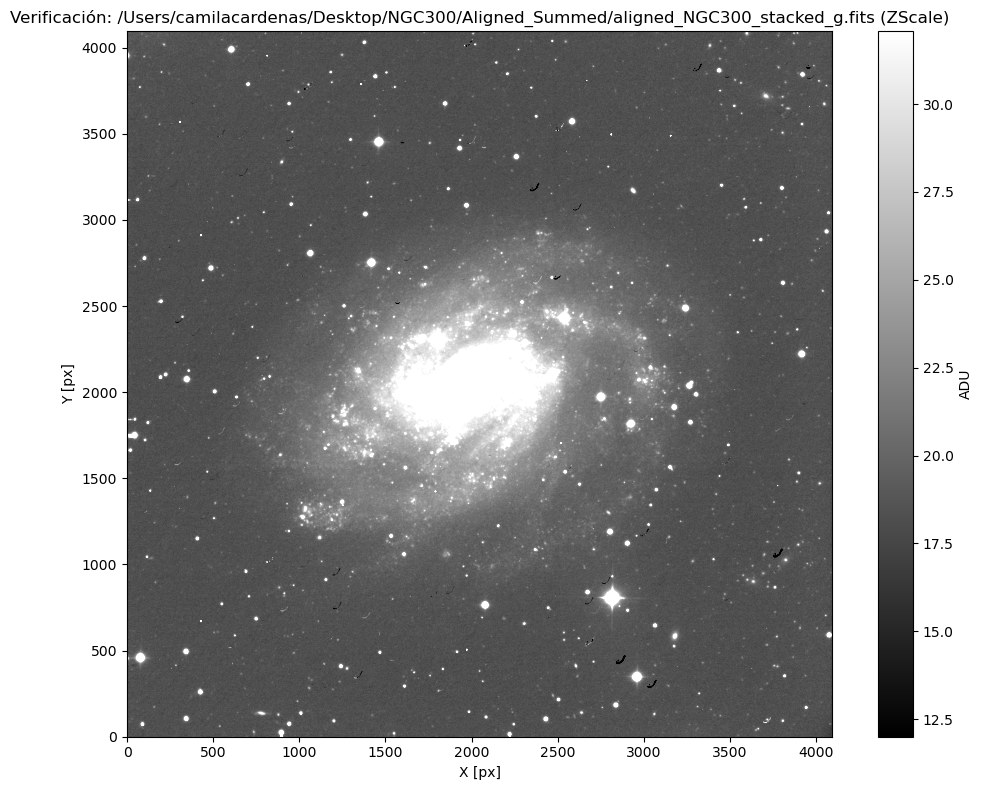

In [14]:
# Nombre del archivo
archivo = "/Users/camilacardenas/Desktop/NGC300/Aligned_Summed/aligned_NGC300_stacked_g.fits"

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(img)

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

104707.39507205157
9.57383121324499e-18
Imagen cargada.
Límites calculados ZScale -> vmin: 2.46, vmax: 35.60


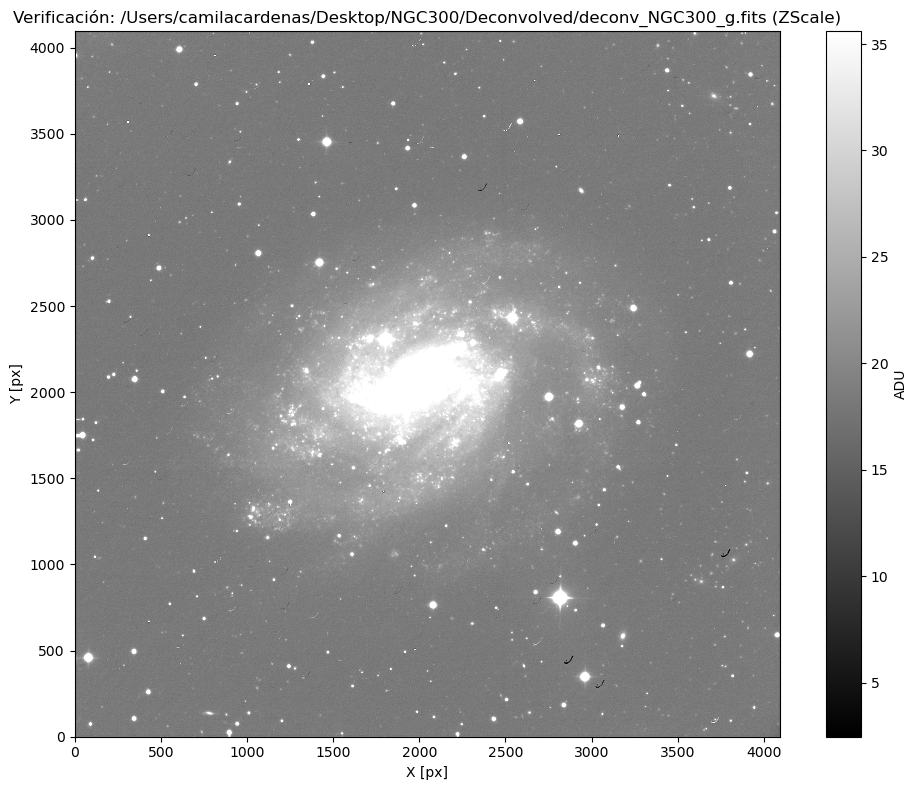

In [15]:
# Nombre del archivo
archivo = "/Users/camilacardenas/Desktop/NGC300/Deconvolved/deconv_NGC300_g.fits"

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(img)

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

### Eliminar hotpixels

In [27]:
import os
import numpy as np
from astropy.io import fits
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

# Base route
base_path = "./"

# Función recursiva para encontrar archivos FITS
def get_fits_files(folder_path, prefix=""):
    files = []
    if not os.path.exists(folder_path):
        return []
    for root, dirs, filenames in os.walk(folder_path):
        for f in filenames:
            if f.lower().startswith(prefix.lower()) and f.lower().endswith(('.fits', '.fit')):
                files.append(os.path.join(root, f))
    return sorted(files)

# CARGA DE ARCHIVOS 
print("Cargando archivos...")

bias_files = get_fits_files(os.path.join(base_path, "Bias"), "bias")
dark_files = get_fits_files(os.path.join(base_path, "Dark"), "dark")
dark_flat_iu_files = get_fits_files(os.path.join(base_path, "Dark_flat", "i_u"), "dark_flat")
dark_flat_gr_files = get_fits_files(os.path.join(base_path, "Dark_flat", "g_r"), "dark_flat")

flat_files_u = get_fits_files(os.path.join(base_path, "Flat", "u"), "flat")
flat_files_i = get_fits_files(os.path.join(base_path, "Flat", "i"), "flat")
flat_files_g = get_fits_files(os.path.join(base_path, "Flat", "g"), "flat")
flat_files_r = get_fits_files(os.path.join(base_path, "Flat", "r"), "flat")

light_files_u = get_fits_files(os.path.join(base_path, "Light", "u"), "NGC300")
light_files_i = get_fits_files(os.path.join(base_path, "Light", "i"), "NGC300")
light_files_g = get_fits_files(os.path.join(base_path, "Light", "g"), "NGC300")
light_files_r = get_fits_files(os.path.join(base_path, "Light", "r"), "NGC300")

if not bias_files: raise ValueError("No se encontraron archivos Bias.")
if not dark_files: print("Warning: No valid dark files found for lights.")

light_by_filter = {
    "u": light_files_u,
    "i": light_files_i,
    "g": light_files_g,
    "r": light_files_r
}

aligned_dir = os.path.join(base_path, "Aligned")
processed_dir = os.path.join(base_path, "Processed")
summed_dir = os.path.join(base_path, "Summed")

os.makedirs(aligned_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)
os.makedirs(summed_dir, exist_ok=True)

# FUNCIONES DE PROCESAMIENTO

def combine_images_mean(file_list):
    """Para Bias y Flats usamos MEAN (menos ruido estadístico)."""
    data_stack = []
    for f in file_list:
        try:
            data = fits.getdata(f).astype(float)
            data_stack.append(data)
        except Exception as e:
            print(f"Error al leer {f}: {str(e)}")
            continue
    if not data_stack: raise ValueError("No images to combine")
    return np.mean(data_stack, axis=0)

# CREACIÓN DE MASTERS 

# A. Master Bias
print("Creando Master Bias...")
master_bias = combine_images_mean(bias_files)
fits.writeto(os.path.join(base_path, "master_bias.fits"), master_bias, overwrite=True)

# B. Master Dark 
print("Creando Master Dark (120s)...")
if dark_files:
    master_dark = combine_images_mean(dark_files) 
    fits.writeto(os.path.join(base_path, "master_dark_120s.fits"), master_dark, overwrite=True)
else:
    master_dark = np.zeros_like(master_bias)

# C. Master Dark Flats
print("Creando Master Dark Flats...")
master_dark_flat_iu = combine_images_mean(dark_flat_iu_files) if dark_flat_iu_files else np.zeros_like(master_bias)
master_dark_flat_gr = combine_images_mean(dark_flat_gr_files) if dark_flat_gr_files else np.zeros_like(master_bias)

# D. Master Flats (Normalización Individual)
master_flats = {}
flat_config = [
    ("u", flat_files_u, master_dark_flat_iu),
    ("i", flat_files_i, master_dark_flat_iu),
    ("g", flat_files_g, master_dark_flat_gr),
    ("r", flat_files_r, master_dark_flat_gr)
]

print("Creando Master Flats (Estrategia: Normalización Individual)...")
for filt, files, dark_flat_ref in flat_config:
    if not files:
        print(f"Warning: No flats found for filter {filt}")
        continue
    try:
        normalized_stack = []
        for f in files:
            data = fits.getdata(f).astype(float)
            corrected = data - dark_flat_ref
            mean_val = np.mean(corrected)
            normalized_frame = corrected / mean_val
            normalized_stack.append(normalized_frame)
        
        master_flat_final = np.mean(normalized_stack, axis=0)
        master_flats[filt] = master_flat_final
        fits.writeto(os.path.join(base_path, f"master_flat_{filt}.fits"), master_flat_final, overwrite=True)
        print(f"Master Flat {filt} creado correctamente.")
    except Exception as e:
        print(f"Error processing flats for filter {filt}: {str(e)}")

# REDUCCIÓN DE IMÁGENES CIENTÍFICAS

def reduce_light(path, filt):
    try:
        data = fits.getdata(path).astype(float)
        if filt not in master_flats:
            raise ValueError(f"No master flat for filter {filt}")
            
        # 1. Calibración estándar
        reduced = (data - master_dark) / master_flats[filt]
        
        # 2. LIMPIEZA DE PÍXELES NEGATIVOS (Evita agujeros negros)
        median_val = np.nanmedian(reduced)
        bad_pixel_mask = reduced < 0 # Solo corregimos los negativos profundos
        reduced[bad_pixel_mask] = median_val

        return reduced
    except Exception as e:
        print(f"Error reducing {path}: {str(e)}")
        return None

# ALINEACIÓN Y EJECUCIÓN

def enhanced_align_images(image_list, reference_image=None, upsample_factor=10):
    if not image_list: return []
    aligned = []
    
    if reference_image is None:
        ref_image = image_list[0]
        aligned.append(ref_image) 
        images_to_align = image_list[1:]
    else:
        ref_image = reference_image
        images_to_align = image_list 
    
    crop_pixels = 50
    h, w = ref_image.shape
    ref_cropped = ref_image[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
    
    for img in images_to_align:
        try:
            img_cropped = img[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
            shift_val, error, diffphase = phase_cross_correlation(
                ref_cropped, img_cropped, upsample_factor=upsample_factor, normalization=None
            )
            shifted = shift(img, shift_val, mode='reflect')
            aligned.append(shifted)
        except Exception as e:
            print(f"Error alineando imagen: {str(e)}")
            aligned.append(img) 
            continue
            
    return aligned

# --- PROCESO PRINCIPAL ---

global_reference_image = None
filters_order = ["r", "i", "g", "u"]

for filt in filters_order:
    files = light_by_filter.get(filt, [])
    
    if files:
        print(f"\nProcesando filtro {filt} con {len(files)} imágenes...")
        
        reduced_imgs = []
        for f in files:
            reduced = reduce_light(f, filt)
            if reduced is not None: reduced_imgs.append(reduced)
        
        if reduced_imgs:
            if global_reference_image is None:
                print("  > Creando referencia de alineación (Master)...")
                aligned_imgs = enhanced_align_images(reduced_imgs, upsample_factor=20)
                global_reference_image = aligned_imgs[0]
            else:
                print(f"  > Alineando filtro {filt} contra referencia (r)...")
                aligned_imgs = enhanced_align_images(reduced_imgs, reference_image=global_reference_image, upsample_factor=20)
            
            for idx, img in enumerate(aligned_imgs):
                out_name = os.path.join(aligned_dir, f"aligned_NGC300_{filt}_{idx+1:03d}.fits")
                fits.writeto(out_name, img, overwrite=True)

# STACKING FINAL (CORREGIDO: MEDIAN)

print("\nGenerando imágenes finales (Stacking)...")
for filt in ["g", "r", "i", "u"]:
    aligned_files = get_fits_files(aligned_dir, f"aligned_NGC300_{filt}")
    if aligned_files:
        stack = []
        for f in aligned_files:
            stack.append(fits.getdata(f).astype(float))
        
        # -------------------------------------------------------------
        # CAMBIO CLAVE: Usamos MEDIAN en lugar de MEAN para las luces.
        # Esto elimina los "gusanos blancos" (trazas de hot pixels)
        # y rayos cósmicos que sobrevivieron.
        # -------------------------------------------------------------
        print(f"  > Combinando {len(stack)} imágenes usando MEDIAN para filtro {filt}...")
        summed = np.median(stack, axis=0)
        
        out_path = os.path.join(summed_dir, f"NGC300_stacked_{filt}.fits")
        fits.writeto(out_path, summed, overwrite=True)
        print(f"Guardado: {out_path}")
    else:
        print(f"No hay imágenes alineadas para filtro {filt}")

print("\nProceso completado.")

Cargando archivos...
Creando Master Bias...
Creando Master Dark (120s)...
Creando Master Dark Flats...
Creando Master Flats (Estrategia: Normalización Individual)...
Master Flat u creado correctamente.
Master Flat i creado correctamente.
Master Flat g creado correctamente.
Master Flat r creado correctamente.

Procesando filtro r con 31 imágenes...
  > Creando referencia de alineación (Master)...

Procesando filtro i con 31 imágenes...
  > Alineando filtro i contra referencia (r)...

Procesando filtro g con 31 imágenes...
  > Alineando filtro g contra referencia (r)...

Procesando filtro u con 9 imágenes...
  > Alineando filtro u contra referencia (r)...

Generando imágenes finales (Stacking)...
  > Combinando 31 imágenes usando MEDIAN para filtro g...
Guardado: ./Summed/NGC300_stacked_g.fits
  > Combinando 31 imágenes usando MEDIAN para filtro r...
Guardado: ./Summed/NGC300_stacked_r.fits
  > Combinando 31 imágenes usando MEDIAN para filtro i...
Guardado: ./Summed/NGC300_stacked_i.fits

In [28]:
# Base path
base_path = "./"
summed_dir = os.path.join(base_path, "Summed")
aligned_summed_dir = os.path.join(base_path, "Aligned_Summed")

# Create output folder if it doesn't exist
os.makedirs(aligned_summed_dir, exist_ok=True)

# Load the stacked images
def load_stacked_images():
    # Definimos los nombres generados en el paso anterior (NGC300)
    # Incluimos el filtro 'u' que faltaba en el snippet original
    stacked_files = {
        'u': os.path.join(summed_dir, "NGC300_stacked_u.fits"),
        'g': os.path.join(summed_dir, "NGC300_stacked_g.fits"),
        'r': os.path.join(summed_dir, "NGC300_stacked_r.fits"),
        'i': os.path.join(summed_dir, "NGC300_stacked_i.fits")
    }
    
    images = {}
    for filt, path in stacked_files.items():
        if os.path.exists(path):
            print(f"Loading {filt}: {path}")
            images[filt] = fits.getdata(path).astype(float)
        else:
            print(f"Warning: File not found for filter {filt}: {path}")
    
    if not images:
        raise FileNotFoundError("No stacked images found in Summed directory.")
        
    return images

# Align images using chi2_shift
def align_with_chi2(images):
    # Check if reference 'r' exists, otherwise pick the first available
    ref_filter = 'r'
    if ref_filter not in images:
        ref_filter = list(images.keys())[0]
        print(f"Warning: Reference filter 'r' not found. Using '{ref_filter}' instead.")
    
    reference = images[ref_filter]
    aligned = {ref_filter: reference}
    
    # Parameters for chi2_shift
    noise_level = np.std(reference)  # Estimate of noise level
    upsample_factor = 'auto' 
    
    print(f"\nStarting alignment with chi2_shift (Reference: {ref_filter})...")
    
    # Iterate over all other filters
    for filt, img in images.items():
        if filt == ref_filter:
            continue # Skip reference
            
        print(f"Aligning filter {filt}...")
        try:
            # Calculate shift
            xoff, yoff, exoff, eyoff = chi2_shift(
                reference, img, noise_level,
                return_error=True, upsample_factor=upsample_factor
            )
            
            # Apply shift (-y, -x ordering is typical for numpy array shifts vs image coords)
            aligned[filt] = img_shift.shiftnd(img, (-yoff, -xoff))
            
            print(f"Displacement {filt}: x={xoff:.2f} ± {exoff:.2f}, y={yoff:.2f} ± {eyoff:.2f}")
        except Exception as e:
            print(f"Error aligning {filt}: {e}. Keeping original.")
            aligned[filt] = img
    
    return aligned

# Save aligned images
def save_aligned_images(aligned_images):
    for filt, img in aligned_images.items():
        # Mantenemos convención de nombres clara
        output_filename = f"aligned_NGC300_stacked_{filt}.fits"
        output_path = os.path.join(aligned_summed_dir, output_filename)
        
        fits.writeto(output_path, img, overwrite=True)
        print(f"Aligned image {filt} saved to: {output_path}")

# Main process
def main():
    try:
        # Load images
        print("--- Loading Stacked Images ---")
        images = load_stacked_images()
        
        # Align images
        aligned_images = align_with_chi2(images)
        
        # Save results
        print("\n--- Saving Aligned Images ---")
        save_aligned_images(aligned_images)
        
        print("\nAlignment completed successfully.")
    except Exception as e:
        print(f"\nCritical Error during the process: {str(e)}")

if __name__ == "__main__":
    main()

--- Loading Stacked Images ---
Loading u: ./Summed/NGC300_stacked_u.fits
Loading g: ./Summed/NGC300_stacked_g.fits
Loading r: ./Summed/NGC300_stacked_r.fits
Loading i: ./Summed/NGC300_stacked_i.fits

Starting alignment with chi2_shift (Reference: r)...
Aligning filter u...
Displacement u: x=0.10 ± 0.03, y=0.51 ± 0.03
Aligning filter g...
Displacement g: x=-0.06 ± 0.00, y=0.13 ± 0.00
Aligning filter i...
Displacement i: x=0.31 ± 0.00, y=0.50 ± 0.00

--- Saving Aligned Images ---
Aligned image r saved to: ./Aligned_Summed/aligned_NGC300_stacked_r.fits
Aligned image u saved to: ./Aligned_Summed/aligned_NGC300_stacked_u.fits
Aligned image g saved to: ./Aligned_Summed/aligned_NGC300_stacked_g.fits
Aligned image i saved to: ./Aligned_Summed/aligned_NGC300_stacked_i.fits

Alignment completed successfully.


66939.19564363544
-177.01020527470183
Imagen cargada.
Límites calculados ZScale -> vmin: 13.35, vmax: 33.93


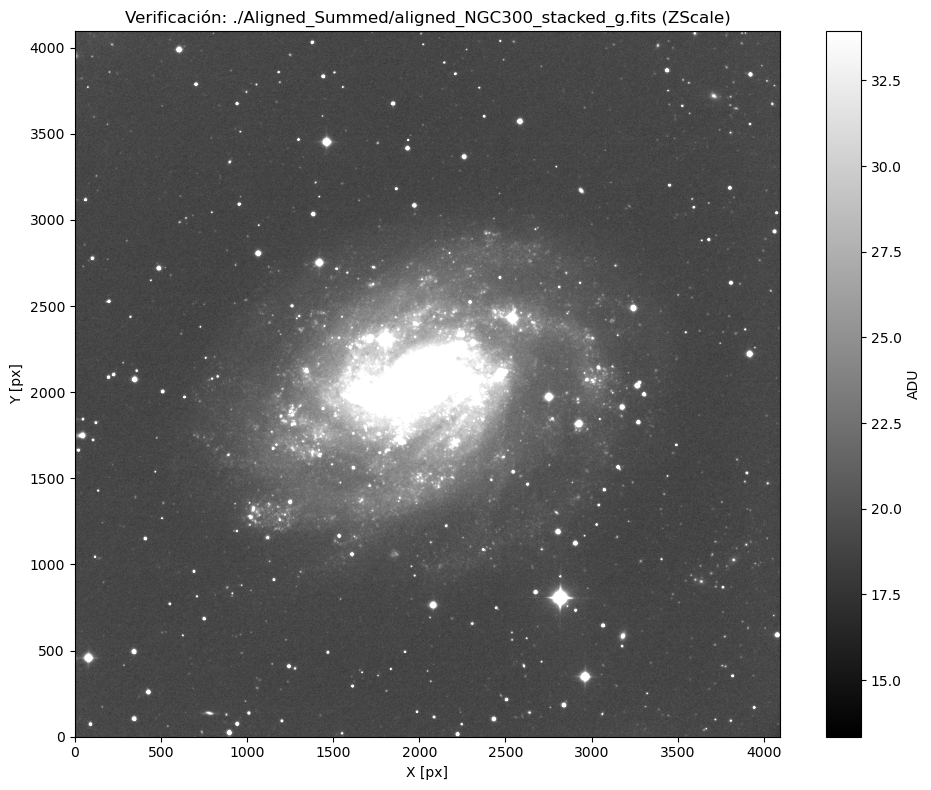

In [30]:
# Nombre del archivo
archivo = "./Aligned_Summed/aligned_NGC300_stacked_g.fits"

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(img)

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

### Deconvolution

In [33]:
# Rutas (basadas en tu código anterior)
base_path = "./"
aligned_dir = os.path.join(base_path, "Aligned_Summed")
deconv_dir = os.path.join(base_path, "Deconvolved")

os.makedirs(deconv_dir, exist_ok=True)

# 1. Función para crear una PSF Gaussiana Sintética
# El documento sugiere usar estrellas no saturadas para ajustar una Gaussiana[cite: 40, 41].
# Aquí creamos una PSF teórica promedio.
def make_gaussian_psf(size=21, sigma=2.0):
    """
    Crea una PSF Gaussiana 2D normalizada.
    size: tamaño de la matriz (impar)
    sigma: desviación estándar (ancho del desenfoque en pixeles)
    """
    x = np.linspace(-(size // 2), size // 2, size)
    y = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(x, y)
    
    # Fórmula Gaussiana básica
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    
    # Normalización: La suma de la PSF debe ser 1 [cite: 38]
    return kernel / np.sum(kernel)

# 2. Algoritmo Richardson-Lucy
# Implementación basada en la Diapositiva 2 
def richardson_lucy(image, psf, num_iter=15):
    """
    Aplica deconvolución RL.
    image: Imagen alineada (stacked)
    psf: Point Spread Function estimada
    num_iter: Número de iteraciones (cuidado: muchas iteraciones = más ruido )
    """
    # Copia inicial de la imagen
    im_deconv = image.copy()
    
    # PSF espejada (necesaria para la convolución en el denominador) [cite: 25, 32]
    psf_mirror = np.flip(psf)
    
    eps = 1e-12 # Para evitar división por cero [cite: 33]
    
    print(f"   > Iniciando {num_iter} iteraciones RL...")
    
    for i in range(num_iter):
        # Paso 1: Convolución de la estimación actual con la PSF
        # u_k (conv) PSF 
        conv = fftconvolve(im_deconv, psf, mode='same') + eps
        
        # Paso 2: Corrección multiplicativa
        # u_{k+1} = u_k * ((I / conv) (conv) PSF*) 
        relative_blur = image / conv
        im_deconv *= fftconvolve(relative_blur, psf_mirror, mode='same')
        
    return im_deconv

# --- PROCESO PRINCIPAL ---

def main():
    # Definimos los filtros a procesar
    filtros = ['u', 'g', 'r', 'i']
    
    # Parámetros de la PSF (Ajustable: Sigma 1.5 a 3.0 suele funcionar bien para telescopios terrestres)
    sigma_psf = 2.0 
    psf = make_gaussian_psf(size=31, sigma=sigma_psf)
    print(f"PSF generada (Sigma={sigma_psf})")

    for filt in filtros:
        input_name = f"aligned_NGC300_stacked_{filt}.fits"
        input_path = os.path.join(aligned_dir, input_name)
        
        if os.path.exists(input_path):
            print(f"\nProcesando filtro {filt}...")
            
            # Cargar imagen
            data = fits.getdata(input_path).astype(float)
            header = fits.getheader(input_path)
            
            # Limpieza básica previa: RL odia los valores negativos (causan artefactos)
            # Reemplazamos negativos con un valor pequeño positivo o cero
            data[data < 0] = 1e-6
            
            # Ejecutar Deconvolución
            try:
                deconvolved_data = richardson_lucy(data, psf, num_iter=15)
                
                # Guardar resultado
                output_name = f"deconv_NGC300_{filt}.fits"
                output_path = os.path.join(deconv_dir, output_name)
                
                # Actualizar header para indicar el proceso
                header['PROCESS'] = 'Richardson-Lucy Deconvolution'
                header['RL_ITER'] = 15
                header['RL_SIGMA'] = sigma_psf
                
                fits.writeto(output_path, deconvolved_data, header, overwrite=True)
                print(f"Guardado: {output_path}")
                
            except Exception as e:
                print(f"Error en deconvolución de {filt}: {e}")
        else:
            print(f"No se encontró: {input_path}")

if __name__ == "__main__":
    main()

PSF generada (Sigma=2.0)

Procesando filtro u...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_u.fits

Procesando filtro g...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_g.fits

Procesando filtro r...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_r.fits

Procesando filtro i...
   > Iniciando 15 iteraciones RL...
Guardado: ./Deconvolved/deconv_NGC300_i.fits


155382.30995953316
2.6396930266080263e-10
Imagen cargada.
Límites calculados ZScale -> vmin: 1.90, vmax: 55.15


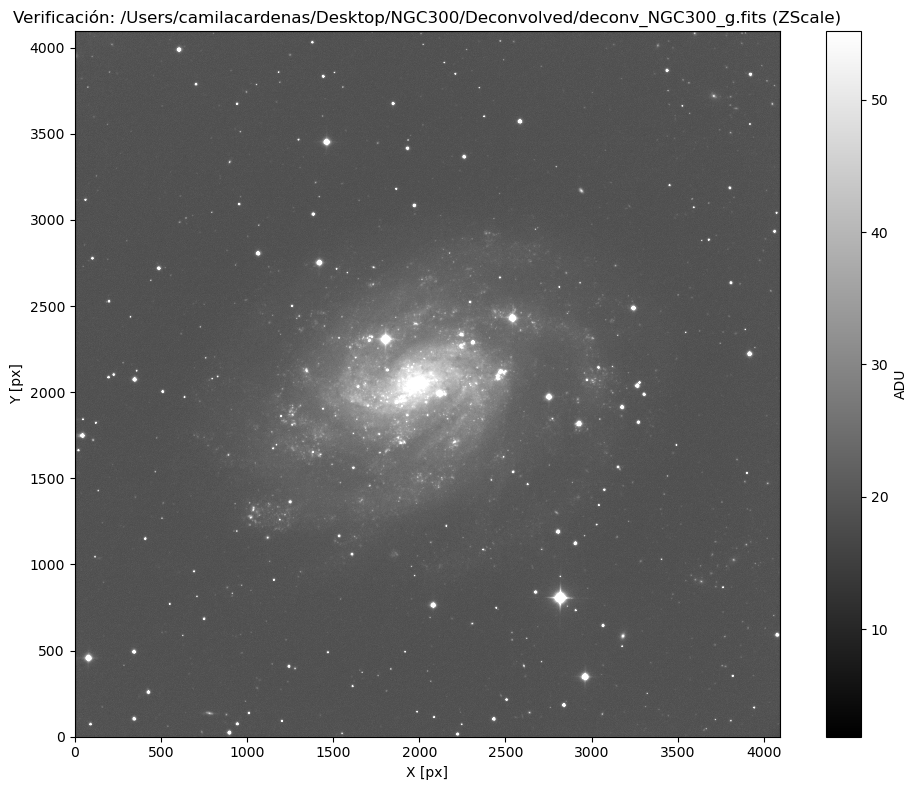

In [38]:
# Nombre del archivo
archivo = "/Users/camilacardenas/Desktop/NGC300/Deconvolved/deconv_NGC300_g.fits"

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = 1.90, 55.15 

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

In [35]:
vmin

1.9068729350337037

In [36]:
vmax

37.52031410085438

Generando panel de imágenes...


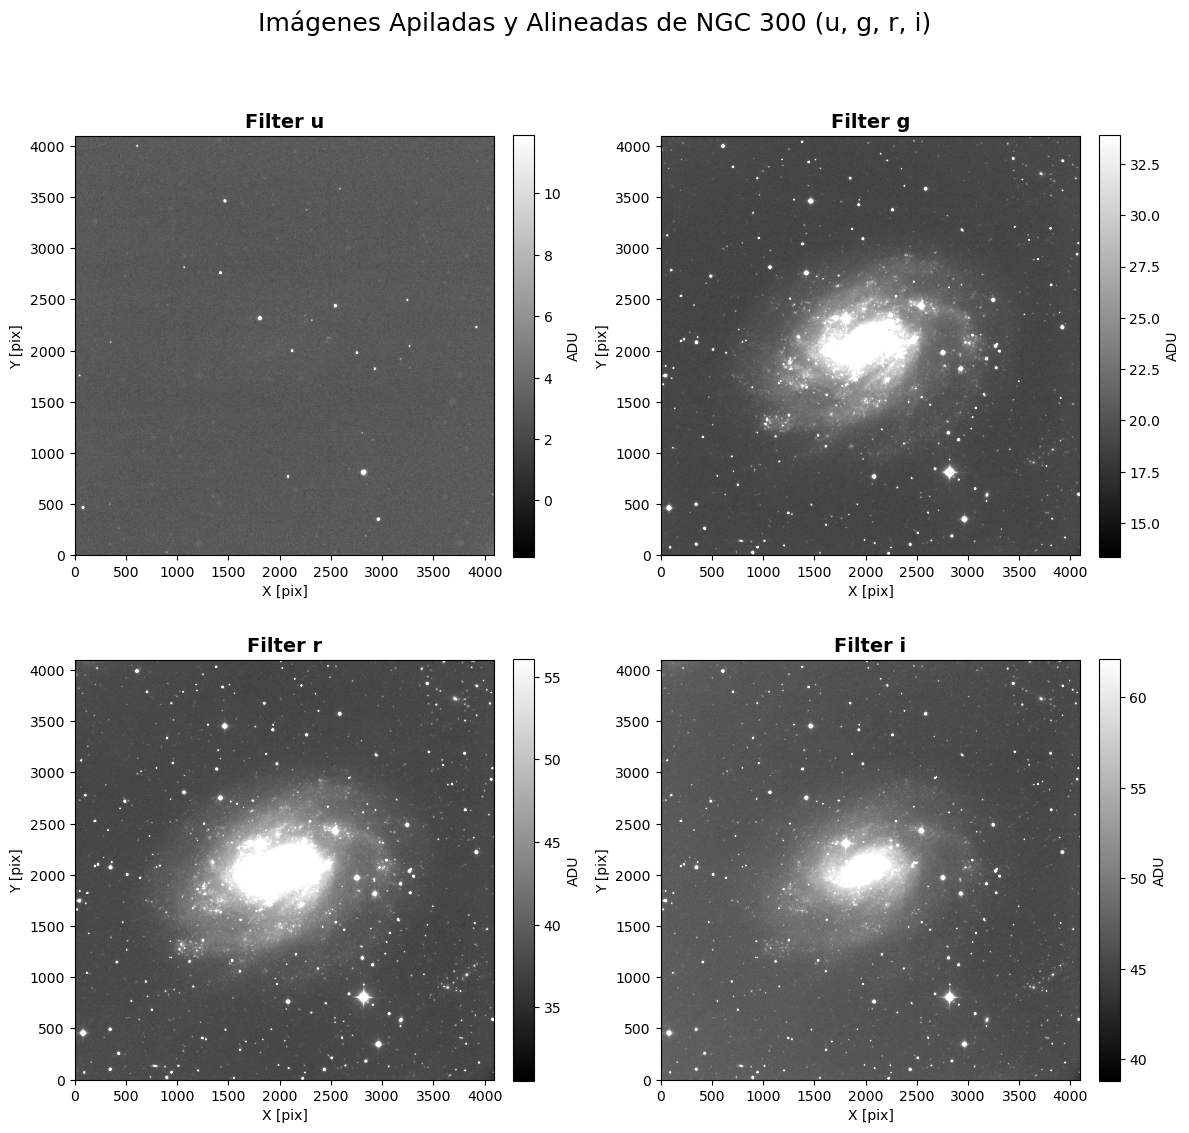

In [4]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Rutas de los archivos (Ajusta si es necesario)
base_dir = "./Aligned_Summed"
files = {
    'u': os.path.join(base_dir, "aligned_NGC300_stacked_u.fits"),
    'g': os.path.join(base_dir, "aligned_NGC300_stacked_g.fits"),
    'r': os.path.join(base_dir, "aligned_NGC300_stacked_r.fits"),
    'i': os.path.join(base_dir, "aligned_NGC300_stacked_i.fits")
}

# Configuración del gráfico
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
filtros = ['u', 'g', 'r', 'i']
axes_flat = axes.flatten()

print("Generando panel de imágenes...")

for idx, filt in enumerate(filtros):
    ax = axes_flat[idx]
    filepath = files[filt]
    
    if os.path.exists(filepath):
        try:
            # 1. Cargar datos
            data = fits.getdata(filepath).astype(float)
            
            # 2. Calcular normalización ZScale (Contraste automático astronómico)
            interval = ZScaleInterval()
            vmin, vmax = interval.get_limits(data)
            
            # 3. Graficar
            im = ax.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
            
            # Decoración
            ax.set_title(f"Filter {filt}", fontsize=14, fontweight='bold')
            ax.set_xlabel("X [pix]")
            ax.set_ylabel("Y [pix]")
            
            # Añadir barra de color pequeña
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='ADU')
            
        except Exception as e:
            print(f"Error al leer {filt}: {e}")
            ax.text(0.5, 0.5, f"Error\n{filt}", ha='center', va='center', color='red')
    else:
        ax.text(0.5, 0.5, f"Archivo no encontrado:\n{filt}", ha='center', va='center', color='red')
        print(f"No encontrado: {filepath}")

# Título general
plt.suptitle("Imágenes Apiladas y Alineadas de NGC 300 (u, g, r, i)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no tape el título
plt.show()

# Opcional: Guardar la figura para tu reporte
# plt.savefig("NGC300_Panel_Final.png", dpi=150)

Generando panel de imágenes...


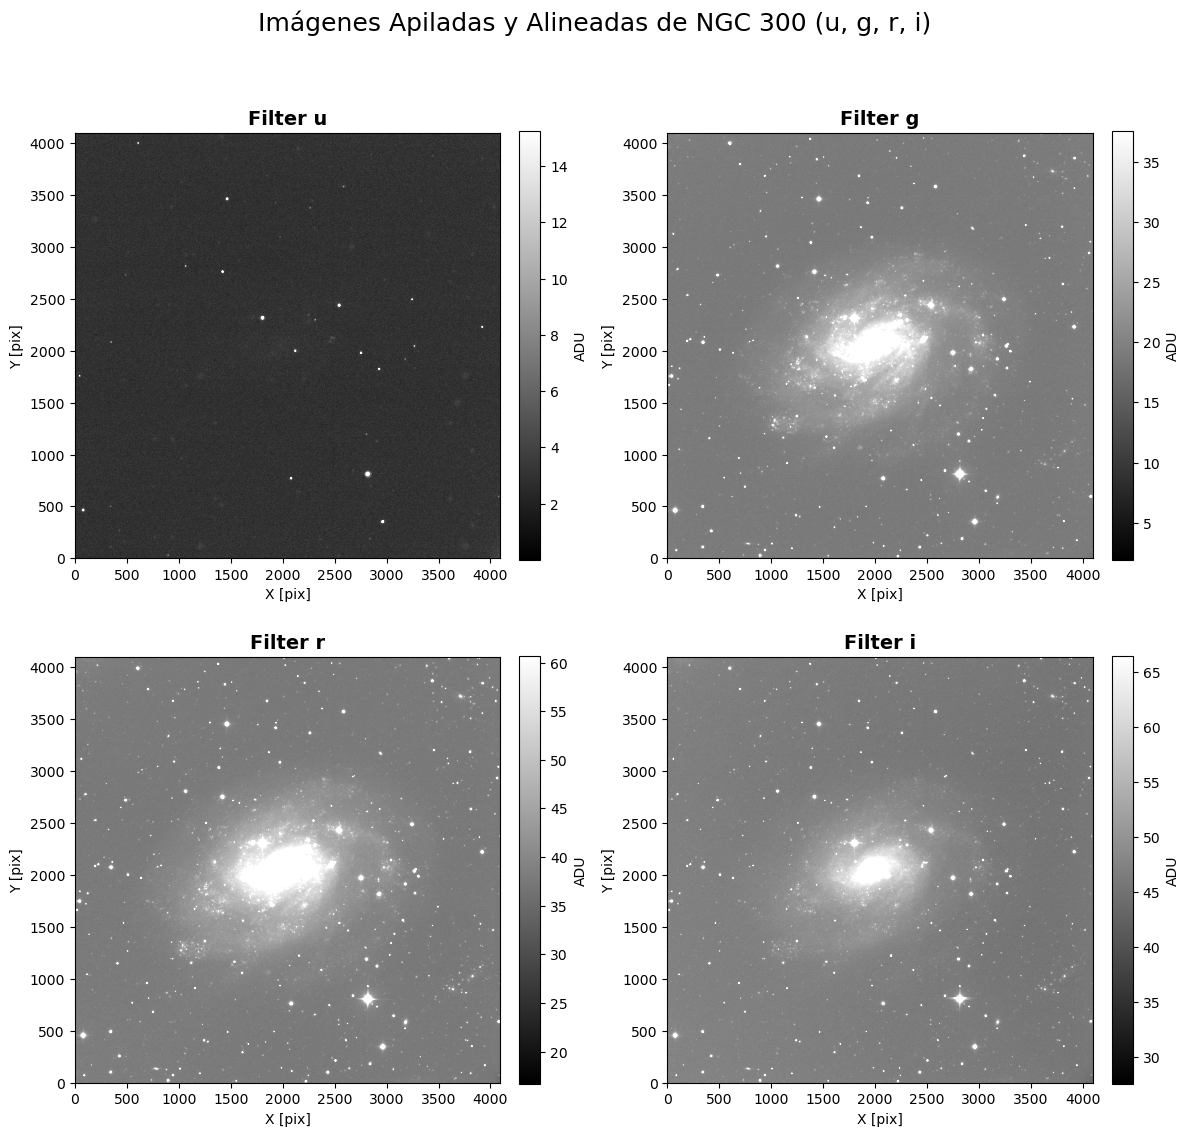

In [16]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Rutas de los archivos (Ajusta si es necesario)
base_dir = "./Deconvolved"
files = {
    'u': os.path.join(base_dir, "deconv_NGC300_u.fits"),
    'g': os.path.join(base_dir, "deconv_NGC300_g.fits"),
    'r': os.path.join(base_dir, "deconv_NGC300_r.fits"),
    'i': os.path.join(base_dir, "deconv_NGC300_i.fits")
}

# Configuración del gráfico
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
filtros = ['u', 'g', 'r', 'i']
axes_flat = axes.flatten()

print("Generando panel de imágenes...")

for idx, filt in enumerate(filtros):
    ax = axes_flat[idx]
    filepath = files[filt]
    
    if os.path.exists(filepath):
        try:
            # 1. Cargar datos
            data = fits.getdata(filepath).astype(float)
            
            # 2. Calcular normalización ZScale (Contraste automático astronómico)
            interval = ZScaleInterval()
            vmin, vmax = interval.get_limits(data)
            
            # 3. Graficar
            im = ax.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
            
            # Decoración
            ax.set_title(f"Filter {filt}", fontsize=14, fontweight='bold')
            ax.set_xlabel("X [pix]")
            ax.set_ylabel("Y [pix]")
            
            # Añadir barra de color pequeña
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='ADU')
            
        except Exception as e:
            print(f"Error al leer {filt}: {e}")
            ax.text(0.5, 0.5, f"Error\n{filt}", ha='center', va='center', color='red')
    else:
        ax.text(0.5, 0.5, f"Archivo no encontrado:\n{filt}", ha='center', va='center', color='red')
        print(f"No encontrado: {filepath}")

# Título general
plt.suptitle("Imágenes Apiladas y Alineadas de NGC 300 (u, g, r, i)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no tape el título
plt.show()

Generando panel con rango dinámico ajustado...


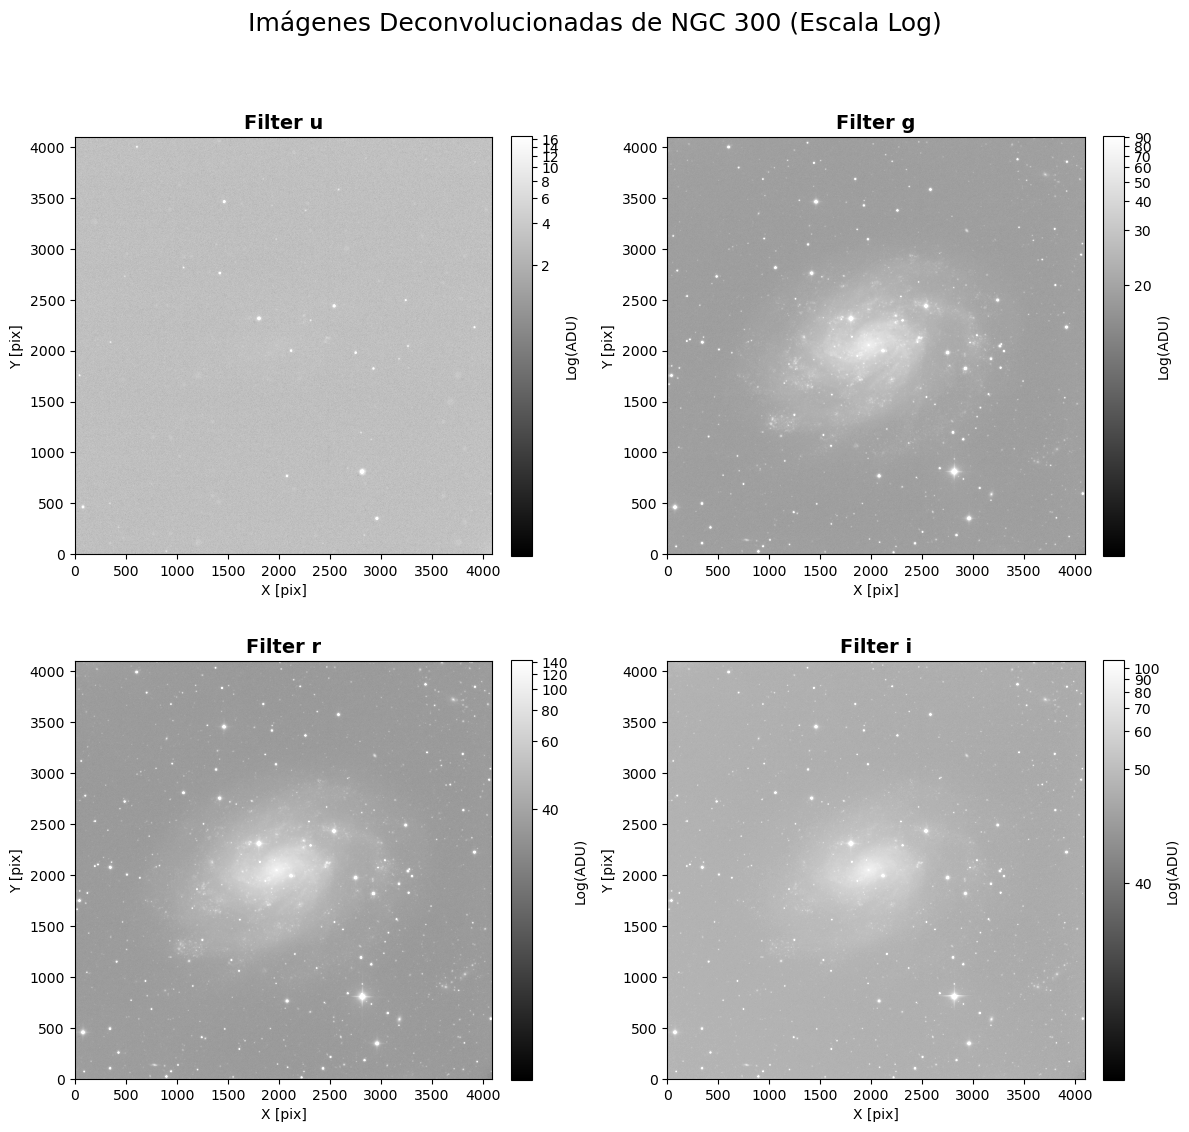

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import AsymmetricPercentileInterval, LogStretch, ImageNormalize

# Rutas de los archivos
base_dir = "./Deconvolved"
files = {
    'u': os.path.join(base_dir, "deconv_NGC300_u.fits"),
    'g': os.path.join(base_dir, "deconv_NGC300_g.fits"),
    'r': os.path.join(base_dir, "deconv_NGC300_r.fits"),
    'i': os.path.join(base_dir, "deconv_NGC300_i.fits")
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
filtros = ['u', 'g', 'r', 'i']
axes_flat = axes.flatten()

print("Generando panel con rango dinámico ajustado...")

for idx, filt in enumerate(filtros):
    ax = axes_flat[idx]
    filepath = files[filt]
    
    if os.path.exists(filepath):
        try:
            data = fits.getdata(filepath).astype(float)
            
            # --- AJUSTE CLAVE ---
            # En lugar de ZScale, usamos un intervalo basado en percentiles
            # lower_percentile=1: Elimina los negros puros (ruido de fondo)
            # upper_percentile=99.5: Sube el límite blanco para incluir el bulbo brillante
            
            # Opción A: Escala Lineal con percentiles más altos (Mejor control del blanco)
            # interval = AsymmetricPercentileInterval(1, 99.8) 
            # vmin, vmax = interval.get_limits(data)
            # norm = None
            
            # Opción B: Escala Logarítmica (La mejor para ver núcleo Y brazos)
            # LogStretch() comprime las luces altas para que el núcleo no sature tanto
            norm = ImageNormalize(data, interval=AsymmetricPercentileInterval(0.5, 99.9), stretch=LogStretch())
            
            # Graficar usando 'norm'
            im = ax.imshow(data, origin='lower', cmap='gist_gray', norm=norm)
            
            ax.set_title(f"Filter {filt}", fontsize=14, fontweight='bold')
            ax.set_xlabel("X [pix]")
            ax.set_ylabel("Y [pix]")
            
            # Barra de color
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Log(ADU)')
            
        except Exception as e:
            print(f"Error al leer {filt}: {e}")
            ax.text(0.5, 0.5, f"Error\n{filt}", ha='center', color='red')
    else:
        ax.text(0.5, 0.5, f"No encontrado:\n{filt}", ha='center', color='red')

plt.suptitle("Imágenes Deconvolucionadas de NGC 300 (Escala Log)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()